# Lung Cancer Sub-phenotyping using Multiple Correspondence Analysis and Consensus Clustering

This document is split into three sections:
<br/> Section 1: Data preprocessing
<br/>Section 2: Model training
<br/> Section 3: Performance Evaluation


## Section 1: Data preprocessing

Following steps are followed in the data preperation:
> 1. Loading packages and preparing environment
> 2. Cleaning data and simplifying existing variables
> 3. Feature selection 
> 4. Imputing missing values
> 5. One-hot encoding of categorical features
> 6. MCA for dimensionality reduction

## Step 1: Loading packages and preparing environment

In [1]:
#pip install pandas boto3 matplotlib numpy seaborn scikit-learn scipy lifelines pylca category_encoders kmodes prince pyclustering lifelines

In [2]:
# Loading relevant packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
import category_encoders as ce
import prince
import matplotlib.cm as cm
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.stats import chi2_contingency
from boto3 import client
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import adjusted_rand_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from lifelines.statistics import multivariate_logrank_test
from kmodes.kmodes import KModes
from lifelines import CoxPHFitter
from itertools import combinations

In [3]:
# Loading aws client and tables
s3 = client("s3")

## Upload full cohort dataset
obj_full_cohort = s3.get_object(Bucket="pm-lc-toronto-22", Key="data/ml_ready/labelled_cohort.csv")
df_full_cohort = pd.read_csv(obj_full_cohort["Body"])

## Loading the labelled cohort
obj_labelled_cohort = s3.get_object(Bucket="pm-lc-toronto-22", Key="data/raw/machine_learning/labelled_cohort.csv")
df_labelled_cohort = pd.read_csv(obj_labelled_cohort["Body"])

In [4]:
## Show all columns of Pandas DataFrame (previously limited to 20 columns)
pd.set_option("display.max_columns", None) 

# Ensuring plots are displayed within notebook
%matplotlib inline

## using ggplot for visualization
plt.style.use('ggplot')
plt.rcParams['axes.grid'] = True

# Set a global seed
np.random.seed(42)

## Step 2: Cleaning data and simplifying existing variables

In [5]:
## Creating a copy of the initial dataset for the analysis
df_analysis = df_full_cohort.copy()

## Add label from labelled cohort to dataset
label_df = df_labelled_cohort[["patient_id", "label"]]
df_analysis = pd.merge(df_analysis, label_df, on='patient_id')

## Renaming "time_of_survival" to "survival"
df_analysis = df_analysis.rename(columns={'time_of_survival': 'survival'})

## Renaming 3A/limited stage and adding to 3A for simpler analysis
df_analysis['stage'] = df_analysis['stage'].str.replace('3A/limited', '3A')

## Adding a simpler stage variable (stage1-4)
df_analysis["stage_simple"] = df_analysis["stage"]
df_analysis.loc[df_analysis['stage_simple'].str.contains('1A|1B', na=False), 'stage_simple'] = '1'
df_analysis.loc[df_analysis['stage_simple'].str.contains('2A|2B', na=False), 'stage_simple'] = '2'
df_analysis.loc[df_analysis['stage_simple'].str.contains('3A|3B', na=False), 'stage_simple'] = '3'
df_analysis.head()

## Changing the light-ex-smoker to just ex-smoker to make visualization better
df_analysis['smoking_status'] = df_analysis['smoking_status'].str.replace('light-ex-smoker', 'ex-smoker')

# Create a new column "type" based on the conditions
df_analysis['type'] = df_analysis['label'].map(lambda x: 'small-cell' if x in ['SCLC late', 'SCLC early', 'Rare late'] else 'non-small-cell')
df_analysis['early_late'] = df_analysis['label'].map(lambda x: 'early stage' if x in ['NSLC early', 'SCLC early'] else 'late stage')

In [6]:
mean_packs_per_year = df_analysis.groupby('smoking_status')['packs_per_year'].mean()
mean_packs_per_year

smoking_status
current-smoker    55.853354
ex-smoker         41.354930
never-smoker       0.000000
Name: packs_per_year, dtype: float64

In [7]:
# Create a pivot table with mean values for 'packs_per_year' and 'age' grouped by 'smoking_status'
pivot_table = df_analysis.pivot_table(index='sex', values=['packs_per_year', 'age'], aggfunc='mean')
pivot_table = pivot_table[['packs_per_year', 'age']]
pivot_table.columns = ['Average Packs per Year', 'Average Age']
print(pivot_table)

        Average Packs per Year  Average Age
sex                                        
Female               38.288782    65.813278
Male                 47.924653    68.261044


In [8]:
## Creating new variable for survival plots based on survival and last_follow_up
df_analysis['survival_overall'] = np.where(df_analysis['patient_status'] == 'Dead', 
                                                df_analysis['survival'], df_analysis['last_follow_up'])

## Adding "event_observed" to df_visualization
df_analysis['event_observed'] = (df_analysis['patient_status'] == 'Dead').astype(int)
df_analysis.head()

## Adding BMI in 14th position
df_analysis['BMI'] = np.nan  # Initialize the "BMI" column with NaN values
valid_indices = (~df_analysis['height'].isna()) & (~df_analysis['weight'].isna())
df_analysis.loc[valid_indices, 'BMI'] = round(df_analysis.loc[valid_indices, 'weight'] / ((df_analysis.loc[valid_indices, 'height'] / 100) ** 2), 2)

## Creating a categorical variable from age
bins = [0, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, float('inf')]
age_labels_model = ['under 30', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80-84', '85-89', '90-94', '95+']
df_analysis['age_category_old'] = pd.cut(df_analysis['age'], bins=bins, labels=age_labels_model)
df_analysis['age_category_old'] = df_analysis['age_category_old'].astype('object')

bins = [0, 40, 50, 60, 70, 80, 90, float('inf')]
labels = ['under 40', '40-49', '50-59', '60-69', '70-79', '80-89', '90+']
df_analysis['age_category'] = pd.cut(df_analysis['age'], bins=bins, labels=labels)
df_analysis['age_category'] = df_analysis['age_category'].astype('object')

# Creating a categorical variable from packs per year
bins = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 100, float('inf')]
packs_labels_model = ['0-4', '5-9', '10-14', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80-84', '85-89', '90-99', '100+']
df_analysis['packs_category_old'] = pd.cut(df_analysis['packs_per_year'], bins=bins, labels=packs_labels_model)
df_analysis['packs_category_old'] = df_analysis['packs_category_old'].astype('object')

bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, float('inf')]
labels = ['0-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89', '90-99', '100+']
df_analysis['packs_category'] = pd.cut(df_analysis['packs_per_year'], bins=bins, labels=labels)
df_analysis['packs_category'] = df_analysis['packs_category'].astype('object')

# Creating a categorical variable from BMI
bins = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, float('inf')]
labels = ['0-5', '5-9', '10-14', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55+']
df_analysis['bmi_category_old'] = pd.cut(df_analysis['BMI'], bins=bins, labels=labels)
df_analysis['bmi_category_old'] = df_analysis['bmi_category_old'].astype('object')

bins = [0, 15, 20, 25, 30, 35, 40, 45, 50, float('inf')]
labels = ['0-14.9', '15-19.9', '20-24.9', '25-29.9', '30-34.9', '35-39.9', '40-44.9', '45-49.9', '50+']
df_analysis['bmi_category'] = pd.cut(df_analysis['BMI'], bins=bins, labels=labels)
df_analysis['bmi_category'] = df_analysis['bmi_category'].astype('object')

## Adjusting molecular alteration
df_analysis.loc[df_analysis['molecular_alteration'] == 'ALK+. EGFR-', 'molecular_alteration'] = 'EGFR-'
df_analysis['molecular_alteration'] = np.where(df_analysis['molecular_alteration'].notna() & (df_analysis['molecular_alteration'] != 'EGFR-'), 'EGFR+', df_analysis['molecular_alteration'])
df_analysis['molecular_alteration'] = df_analysis['molecular_alteration'].fillna('EGFR-')

In [9]:
df_analysis["molecular_alteration"].value_counts()

molecular_alteration
EGFR-    382
EGFR+    108
Name: count, dtype: int64

## Step 3: Feature selection

In [10]:
## Selecting only clinically relevant features based on feedback from Ella
df_analysis.head()

# Selecting a subset of columns
relevant_columns = ['age_category','sex', 'race', 'marital_status', 'stage', 'bmi_category',
                    'asbestos_exposure', "alcohol_consumption", 'health_status', 'histology', 'molecular_alteration', 'packs_category', 'smoking_status', 
                    'symptoms_past_week', 'asbestosis', 'chronic_bronchitis','chronic_kidney_disease','depression','diabetes',
                    'emphysema', 'heart_failure', 'hypertension', 'inflammatory_bowel_disease', 'kidney_problems',
                    'liver_disease', 'myocardial infarction', 'pancreatic_disease', 'shortness_of_breath',
                    'stroke', 'intent_of_care']

relevant_columns_new = ['age_category','sex', 'race', 'stage','bmi_category', 'marital_status',
                    'asbestos_exposure', "alcohol_consumption", 'histology', 'molecular_alteration', 'packs_category', 'smoking_status', 
                    'asbestosis', 'chronic_bronchitis','chronic_kidney_disease','depression','diabetes',
                    'emphysema', 'heart_failure', 'hypertension', 'inflammatory_bowel_disease', 'kidney_problems',
                    'liver_disease', 'myocardial infarction', 'pancreatic_disease', 'shortness_of_breath',
                    'stroke']

df_analysis_subset = df_analysis[relevant_columns_new]
df_analysis_subset.head()

,age_category,sex,race,stage,bmi_category,marital_status,asbestos_exposure,alcohol_consumption,histology,molecular_alteration,packs_category,smoking_status,asbestosis,chronic_bronchitis,chronic_kidney_disease,depression,diabetes,emphysema,heart_failure,hypertension,inflammatory_bowel_disease,kidney_problems,liver_disease,myocardial infarction,pancreatic_disease,shortness_of_breath,stroke
0,70-79,Female,White/Caucasian,4,15-19.9,Single,No,NaN,Squamous cell carcinoma,EGFR-,50-59,ex-smoker,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
1,80-89,Female,White/Caucasian,1A,25-29.9,Single,No,No,Adenocarcinoma,EGFR-,10-19,ex-smoker,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,40-49,Female,NaN,4,NaN,NaN,NaN,NaN,Adenocarcinoma,EGFR+,NaN,never-smoker,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,70-79,Male,White/Caucasian,4,NaN,Single,No,No,Small cell carcinoma,EGFR-,0-9,current-smoker,No,No,No,No,No,No,No,No,Yes,No,No,No,No,No,No
4,80-89,Female,Mixed,1A,25-29.9,Divorced,No,Yes,Adenocarcinoma,EGFR-,0-9,ex-smoker,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df_analysis_subset.shape

(490, 27)

## Step 4: Imputing missing values

In [12]:
## showing NaN values in packs per year based on smoking status
nan_counts = df_analysis_subset.groupby('smoking_status')['packs_category'].apply(lambda x: x.isna().sum())

ex_smoker_mean = df_analysis_subset.loc[df_analysis_subset['smoking_status'] == 'ex-smoker', 'packs_category'].mode()
df_analysis_subset.loc[df_analysis_subset['smoking_status'] == 'ex-smoker', 'packs_category'].fillna(ex_smoker_mean, inplace=True)
df_analysis_subset.loc[df_analysis_subset['smoking_status'] == 'never smoker', 'packs_category'].fillna(0, inplace=True)

In [13]:
## Replacing NaN values with missing data for specific variables where it doesn't apply
column_index_of_molecular_alteration = df_analysis_subset.columns.get_loc('molecular_alteration')
df_analysis_subset.iloc[:, column_index_of_molecular_alteration] = df_analysis_subset.iloc[:, column_index_of_molecular_alteration].fillna('missing')

In [14]:
## Copying standardized df 
df_analysis_subset_imputed = df_analysis_subset.copy() 

In [15]:
## Checking all NaN values
nan_percentage = df_analysis_subset_imputed.isna().mean() * 100
print(nan_percentage)

age_category                   0.000000
sex                            0.000000
race                          17.551020
stage                          2.040816
bmi_category                  25.306122
marital_status                16.530612
asbestos_exposure             25.714286
alcohol_consumption           38.367347
histology                      2.040816
molecular_alteration           0.000000
packs_category                25.306122
smoking_status                 0.000000
asbestosis                    61.224490
chronic_bronchitis            61.428571
chronic_kidney_disease        57.346939
depression                    57.551020
diabetes                      56.530612
emphysema                     60.816327
heart_failure                 56.530612
hypertension                  56.122449
inflammatory_bowel_disease    57.142857
kidney_problems               57.142857
liver_disease                 57.142857
myocardial infarction         55.918367
pancreatic_disease            56.938776


In [16]:
df_analysis_subset_imputed["smoking_status"].value_counts()

smoking_status
ex-smoker         286
never-smoker      122
current-smoker     82
Name: count, dtype: int64

In [17]:
# Check data types for categorical variables in df_analysis_subset_imputed
categorical_vars = []
for column in df_analysis_subset_imputed.columns:
    if df_analysis_subset_imputed[column].dtype == 'object':
        categorical_vars.append(column)

# Calculate NaN percentages for categorical variables
nan_percentage = df_analysis_subset_imputed[categorical_vars].isna().mean() * 100
nan_percentage_sorted = nan_percentage.sort_values(ascending=False)

# Perform mode imputation for each categorical variable
imputer = SimpleImputer(strategy='most_frequent')

# Impute missing values in categorical variables
df_analysis_subset_imputed[categorical_vars] = imputer.fit_transform(df_analysis_subset_imputed[categorical_vars])

In [18]:
df_analysis_subset_imputed.head(10)

,age_category,sex,race,stage,bmi_category,marital_status,asbestos_exposure,alcohol_consumption,histology,molecular_alteration,packs_category,smoking_status,asbestosis,chronic_bronchitis,chronic_kidney_disease,depression,diabetes,emphysema,heart_failure,hypertension,inflammatory_bowel_disease,kidney_problems,liver_disease,myocardial infarction,pancreatic_disease,shortness_of_breath,stroke
0,70-79,Female,White/Caucasian,4,15-19.9,Single,No,No,Squamous cell carcinoma,EGFR-,50-59,ex-smoker,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
1,80-89,Female,White/Caucasian,1A,25-29.9,Single,No,No,Adenocarcinoma,EGFR-,10-19,ex-smoker,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
2,40-49,Female,White/Caucasian,4,20-24.9,Single,No,No,Adenocarcinoma,EGFR+,40-49,never-smoker,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
3,70-79,Male,White/Caucasian,4,20-24.9,Single,No,No,Small cell carcinoma,EGFR-,0-9,current-smoker,No,No,No,No,No,No,No,No,Yes,No,No,No,No,No,No
4,80-89,Female,Mixed,1A,25-29.9,Divorced,No,Yes,Adenocarcinoma,EGFR-,0-9,ex-smoker,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
5,80-89,Male,White/Caucasian,4,30-34.9,Single,No,Yes,Squamous cell carcinoma,EGFR-,80-89,current-smoker,No,Yes,No,No,No,No,No,No,No,No,No,No,No,Yes,No
6,50-59,Male,Latino/Hispanics,4,20-24.9,Single,No,No,Small cell carcinoma,EGFR-,30-39,ex-smoker,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
7,50-59,Male,White/Caucasian,1A,20-24.9,Single,No,No,Other,EGFR-,40-49,never-smoker,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
8,60-69,Female,White/Caucasian,4,20-24.9,Divorced,No,No,Adenocarcinoma,EGFR+,10-19,ex-smoker,No,No,No,No,No,No,No,Yes,No,No,No,No,No,No,No
9,60-69,Female,White/Caucasian,3A,20-24.9,Single,No,No,Small cell carcinoma,EGFR-,30-39,ex-smoker,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No


In [19]:
## checking that all NaN values are gone
nan_counts = df_analysis_subset_imputed.isnull().sum()
nan_columns = nan_counts[nan_counts > 0]
nan_columns_sorted = nan_columns.sort_values(ascending=True)
nan_columns_sorted #empty

Series([], dtype: int64)

## Step 5: One-hot encoding

In [20]:
# Select only the categorical features from your dataset
categorical_features = df_analysis_subset_imputed.select_dtypes(include=['object', 'category'])
categorical_features.describe()

# Perform one-hot encoding
encoded_features = pd.get_dummies(categorical_features)

# Concatenate the encoded features with the original DataFrame
df_encoded = pd.concat([df_analysis_subset_imputed, encoded_features], axis=1)

# Remove the original categorical features
df_encoded.drop(categorical_features.columns, axis=1, inplace=True)
#df_encoded.head()
df_encoded.shape

(490, 91)

In [21]:
## trying binary encoding
# Select only the categorical features from your dataset
categorical_features = df_analysis_subset_imputed.select_dtypes(include=['object', 'category'])

# Initialize BinaryEncoder
binary_encoder = ce.BinaryEncoder(cols=categorical_features.columns)

# Fit and transform the categorical features
encoded_features_binary = binary_encoder.fit_transform(categorical_features)

# Concatenate the encoded features with the original DataFrame
df_encoded_binary = pd.concat([df_analysis_subset_imputed, encoded_features_binary], axis=1)

# Remove the original categorical features
df_encoded_binary.drop(categorical_features.columns, axis=1, inplace=True)
#df_encoded_binary.head()
df_encoded_binary.shape

(490, 63)

## Step 6: MCA for dimensionality reduction

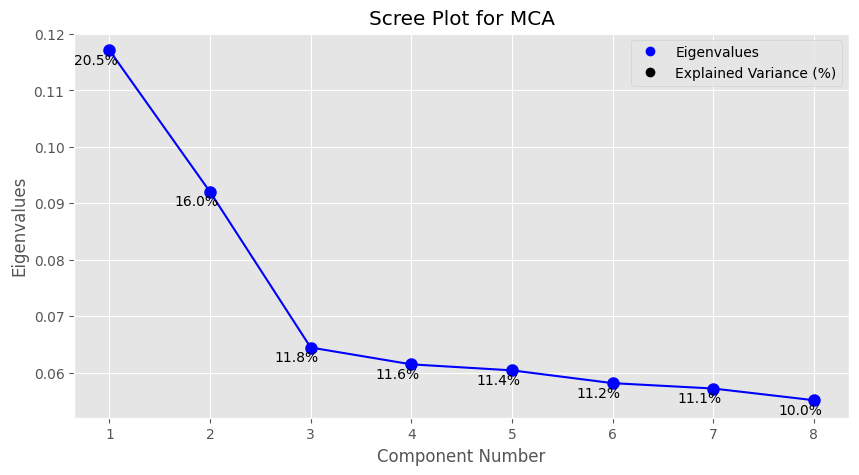

In [22]:
# Perform MCA
mca = prince.MCA(n_components=-1) # Extract all components
mca = mca.fit(df_analysis_subset_imputed)

# Get the inertia (eigenvalues) for each component
inertia = mca.eigenvalues_

# Given explained variance ratios
explained_variance_ratio = [0.205, 0.16, 0.118, 0.116, 0.114, 0.112, 0.111, 0.10]

# Plot the scree plot
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(inertia) + 1), inertia, 'bo-', markersize=8)

# Annotate points with explained variance in percentage
for i, explained_variance in enumerate(explained_variance_ratio, start=1):
    plt.annotate(f'{explained_variance * 100:.1f}%', (i, inertia[i-1]), textcoords="offset points", xytext=(-10,-10), ha='center', color='black')

plt.xlabel('Component Number')
plt.ylabel('Eigenvalues')
plt.title('Scree Plot for MCA')
plt.xticks(range(1, len(inertia) + 1))
plt.grid(True)

# Create a custom legend
from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], marker='o', color='blue', lw=0),
                Line2D([0], [0], marker='o', color='black', lw=0)]
plt.legend(custom_lines, ['Eigenvalues', 'Explained Variance (%)'])

# Show the plot
plt.show()


In [23]:
# Perform MCA to reduce dimensionality
mca = prince.MCA(n_components=3)

# Fit the MCA model to your data
mca = mca.fit(df_analysis_subset_imputed)

# Transform the data
df_encoded_mca = mca.transform(df_analysis_subset_imputed)
df_encoded_mca.shape

(490, 3)

## Section 2: Model training
This section trains three models: k-means, hierarchical and gaussian mixture models (GMM). It goes through each algorithm, fits it to the data, chooses the optimal number of clusters (k) and calculates evaluation metrics such as the silhouette score.

### Algorithm 1: K-means

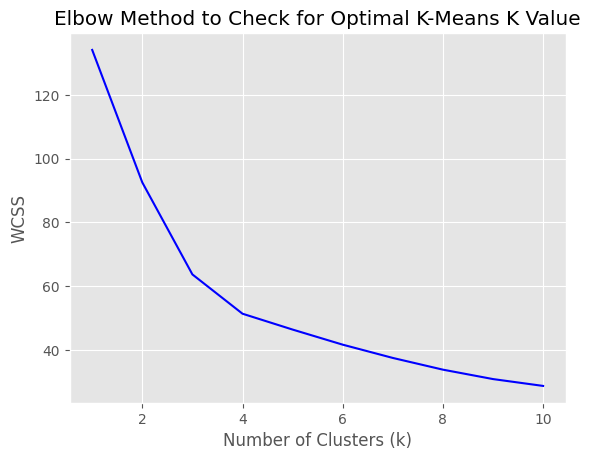

In [24]:
## Creating elbow method graph to check for optimal k
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, n_init=10)
    kmeans.fit(df_encoded_mca)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, color="b")
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method to Check for Optimal K-Means K Value')
plt.show()

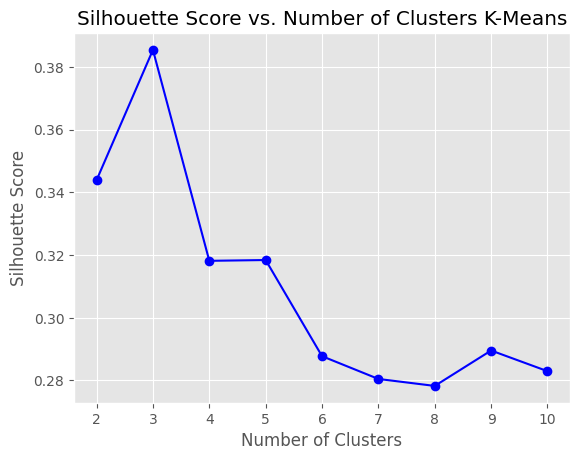

In [25]:
# Define the range of cluster numbers to evaluate
min_clusters = 2
max_clusters = 10
cluster_range = range(min_clusters, max_clusters+1)

# Create an empty list to store the silhouette scores
silhouette_scores = []

# Iterate over the cluster range
for k in cluster_range:
    # Fit the KMeans model with the current number of clusters
    kmeans = KMeans(n_clusters=k, random_state=24, n_init=10)
    clusters = kmeans.fit_predict(df_encoded_mca)
    
    # Calculate the silhouette score for the current clustering solution
    score = silhouette_score(df_encoded_mca, clusters)
    silhouette_scores.append(score)

# Plotting the silhouette scores
plt.plot(cluster_range, silhouette_scores, marker='o', color="b")
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters K-Means')
plt.show()

In [26]:
kmeans = KMeans(n_clusters=3, random_state=24, n_init=10)
kmeans.fit(df_encoded_mca)
clusters_kmeans = kmeans.labels_
clusters_kmeans = clusters_kmeans + 1

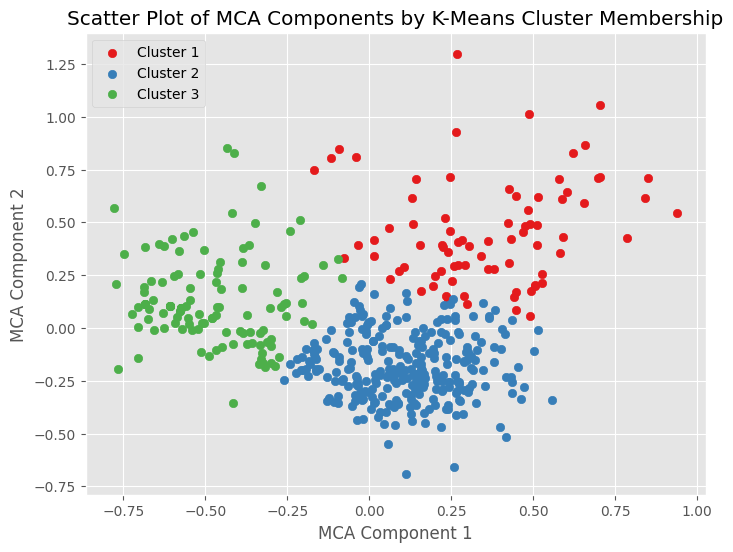

In [27]:
## create mca kmeans dataframe for scatterplot
df_encoded_mca_kmeans = df_encoded_mca.copy()
df_encoded_mca_kmeans['Clusters_kmeans'] = clusters_kmeans
df_encoded_mca_kmeans['Clusters_kmeans'] = df_encoded_mca_kmeans['Clusters_kmeans'].astype('category')

# Extract the first two components from the MCA-transformed data
component_1 = df_encoded_mca_kmeans.iloc[:, 0].values
component_2 = df_encoded_mca_kmeans.iloc[:, 1].values

# Get the values from the fourth column for coloring
color_column = df_encoded_mca_kmeans.iloc[:, 3].astype('category')  # Treat as categorical

# Create a scatter plot
plt.figure(figsize=(8, 6))

# Get seaborn color palette as list of RGB values
palette = sns.color_palette('Set1', len(color_column.cat.categories))

# Define colors for each category
categories = color_column.cat.categories
color_map = {category: color for category, color in zip(categories, palette)}  # Map categories to colors

# Plot each category separately with the corresponding color
for i, category in enumerate(categories):
    mask = color_column == category
    plt.scatter(component_1[mask], component_2[mask], color=color_map[category], label='Cluster {}'.format(category))

plt.xlabel('MCA Component 1')
plt.ylabel('MCA Component 2')
plt.title('Scatter Plot of MCA Components by K-Means Cluster Membership')

# Add color keys for column labels
plt.legend(loc='upper left')
plt.show()


In [28]:
## Creating a new df on which to do analysis - original df_analysis_subet_imputed + cluster membership
df_analysis_final = df_analysis_subset_imputed.copy()
df_analysis_final['Clusters_kmeans'] = clusters_kmeans
df_analysis_final['Clusters_kmeans'] = df_analysis_final['Clusters_kmeans'].astype('category')

## adding survival and packs per year back
df_analysis_final['survival_overall'] = df_analysis["survival_overall"]
df_analysis_final['packs_per_year'] = df_analysis["packs_per_year"]
df_analysis_final.head()

## simplifying stage 

,age_category,sex,race,stage,bmi_category,marital_status,asbestos_exposure,alcohol_consumption,histology,molecular_alteration,packs_category,smoking_status,asbestosis,chronic_bronchitis,chronic_kidney_disease,depression,diabetes,emphysema,heart_failure,hypertension,inflammatory_bowel_disease,kidney_problems,liver_disease,myocardial infarction,pancreatic_disease,shortness_of_breath,stroke,Clusters_kmeans,survival_overall,packs_per_year
0,70-79,Female,White/Caucasian,4,15-19.9,Single,No,No,Squamous cell carcinoma,EGFR-,50-59,ex-smoker,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,2,2.0,51.00
1,80-89,Female,White/Caucasian,1A,25-29.9,Single,No,No,Adenocarcinoma,EGFR-,10-19,ex-smoker,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,2,41.0,15.75
2,40-49,Female,White/Caucasian,4,20-24.9,Single,No,No,Adenocarcinoma,EGFR+,40-49,never-smoker,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,3,30.0,NaN
3,70-79,Male,White/Caucasian,4,20-24.9,Single,No,No,Small cell carcinoma,EGFR-,0-9,current-smoker,No,No,No,No,No,No,No,No,Yes,No,No,No,No,No,No,2,16.0,7.00
4,80-89,Female,Mixed,1A,25-29.9,Divorced,No,Yes,Adenocarcinoma,EGFR-,0-9,ex-smoker,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,2,35.0,6.50


In [29]:
## calculating silhouette score of k-means
silhouette_avg = silhouette_score(df_encoded_mca, clusters_kmeans)
print("Silhouette Score:", silhouette_avg)

## score ranges from -1 to 1 - closer to +1 is good cluster, closer to -1 is bad

Silhouette Score: 0.3854826213950414


In [30]:
## calculating the Calinski-Harabasz Index
ch_score = calinski_harabasz_score(df_encoded_mca, clusters_kmeans)
print("Calinski-Harabasz Index:", ch_score)

## A higher CHI score suggests good separation between clusters, meaning that the clusters are distinct and well-separated.
## A lower CHI score indicates less separation and less distinctiveness among the clusters. It could suggest overlapping or ambiguous clusters.

Calinski-Harabasz Index: 269.3148630305714


In [31]:
# Calculate the Davies-Bouldin Index
dbi_score = davies_bouldin_score(df_encoded_mca, clusters_kmeans)
print("Davies-Bouldin Index:", dbi_score)

#The Davies-Bouldin Index measures the average similarity between each cluster and its most similar cluster, 
#taking into account both the separation and compactness of clusters. 
#A lower Davies-Bouldin Index indicates better clustering, 
#with lower values indicating more distinct and well-separated clusters.

Davies-Bouldin Index: 0.9870828091047592


In [32]:
## getting feeling for size of clusters
unique_labels, cluster_sizes = np.unique(clusters_kmeans, return_counts=True)

# Print the size of each cluster
for label, size in zip(unique_labels, cluster_sizes):
    print("Cluster {}: Size = {}".format(label, size))

Cluster 1: Size = 80
Cluster 2: Size = 286
Cluster 3: Size = 124


In [33]:
df_analysis_final["molecular_alteration"].value_counts()

molecular_alteration
EGFR-    382
EGFR+    108
Name: count, dtype: int64

In [34]:
## Attempting to run K-modes on categorical data (not MCA-reduced)
km = KModes(n_clusters=4, init='Huang', n_init=1, verbose=1)  
clusters_kmodes = km.fit_predict(df_analysis_subset_imputed)

# Convert categorical data to numerical form using one-hot encoding
encoder = OneHotEncoder(sparse=False)
data_encoded = encoder.fit_transform(df_analysis_subset_imputed)

# Calculate silhouette score
silhouette_avg = silhouette_score(data_encoded, clusters_kmodes)
print("Silhouette Score:", silhouette_avg)

# not good results - silhouette score of 0.081

Init: initializing centroids
Init: initializing clusters


Starting iterations...
Run 1, iteration: 1/100, moves: 150, cost: 2154.0
Run 1, iteration: 2/100, moves: 34, cost: 2154.0
Silhouette Score: 0.06589626747283714


/home/ubuntu/new_venv/lib/python3.8/site-packages/sklearn/preprocessing/_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


### Algorithm 2: Hierarchical Clustering

In [35]:
# Create an instance of the AgglomerativeClustering class
clustering = AgglomerativeClustering()  # Specify the desired number of clusters

# Fit the data and obtain the cluster labels
clusters_hierarchical = clustering.fit_predict(df_encoded_mca)

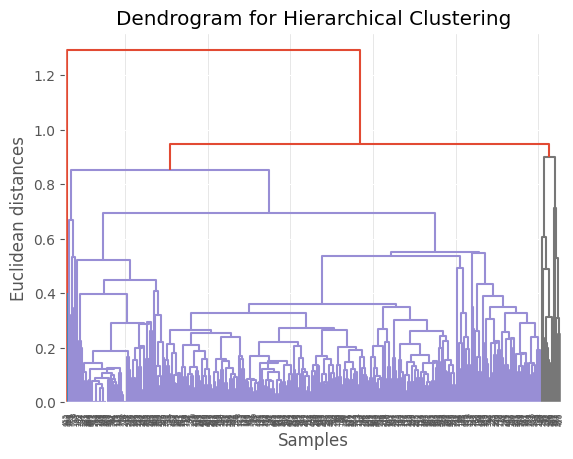

In [36]:
# Plot the dendrogram
dendrogram = sch.dendrogram(sch.linkage(df_encoded_mca, method='centroid'))
plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Samples')
plt.ylabel('Euclidean distances')
plt.show()

based on the above dendogram, we can choose the optimal number of clusters: 3

A dendrogram is a tree-like diagram that displays the sequences of merges or splits. By visualizing the dendrogram, you can observe at which point the combination of clusters is most significant. The "elbow" or the point where the height of the merges increases substantially can be taken as the optimal number of clusters. The height represents the dissimilarity between clusters.

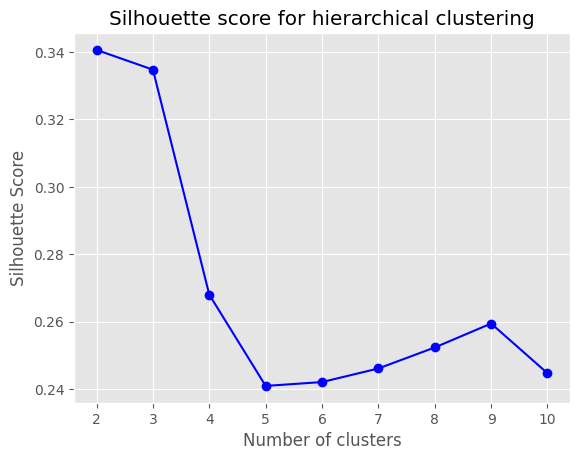

In [37]:
scores = []
for k in range(2, 11):
    clustering = AgglomerativeClustering(n_clusters=k)
    clusters = clustering.fit_predict(df_encoded_mca)
    score = silhouette_score(df_encoded_mca, clusters)
    scores.append(score)

plt.plot(range(2, 11), scores, marker='o', color="b")
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title("Silhouette score for hierarchical clustering")
plt.show()

In [38]:
## re-running hierarchical clustering with optimal number of clusters
optimal_k = 3

# Re-run hierarchical clustering with the optimal number of clusters
final_clustering = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
final_hierarchical_clusters = final_clustering.fit_predict(df_encoded_mca)
final_hierarchical_clusters = final_hierarchical_clusters + 1
df_analysis_final['Clusters_hierarchical'] = final_hierarchical_clusters

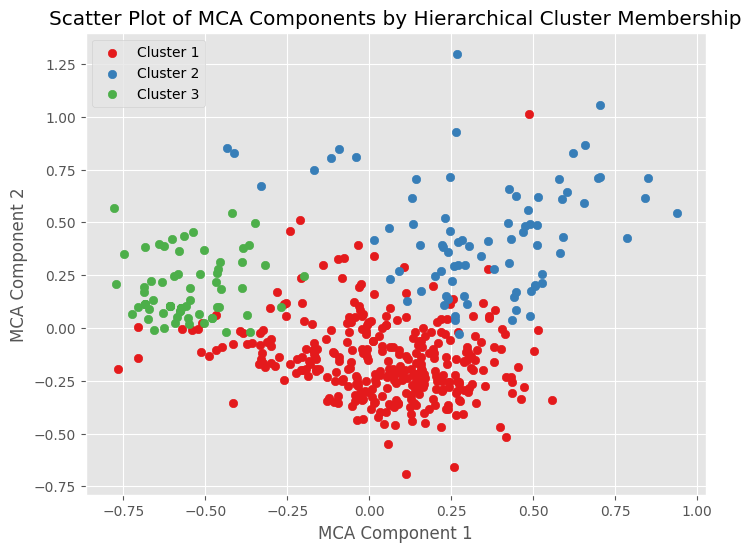

In [39]:
## create mca kmeans dataframe for scatterplot
df_encoded_mca_hierarchical = df_encoded_mca.copy()
df_encoded_mca_hierarchical['Clusters_hierarchical'] = final_hierarchical_clusters
df_encoded_mca_hierarchical['Clusters_hierarchical'] = df_encoded_mca_hierarchical['Clusters_hierarchical'].astype('category')

# Extract the first two components from the MCA-transformed data
component_1 = df_encoded_mca_hierarchical.iloc[:, 0].values
component_2 = df_encoded_mca_hierarchical.iloc[:, 1].values

# Get the values from the fourth column for coloring
color_column = df_encoded_mca_hierarchical.iloc[:, 3].astype('category')  # Treat as categorical

# Create a scatter plot
plt.figure(figsize=(8, 6))

# Get seaborn color palette as list of RGB values
palette = sns.color_palette('Set1', len(color_column.cat.categories))

# Define colors for each category
categories = color_column.cat.categories
color_map = {category: color for category, color in zip(categories, palette)}  # Map categories to colors

# Plot each category separately with the corresponding color
for i, category in enumerate(categories):
    mask = color_column == category
    plt.scatter(component_1[mask], component_2[mask], color=color_map[category], label='Cluster {}'.format(category))

plt.xlabel('MCA Component 1')
plt.ylabel('MCA Component 2')
plt.title('Scatter Plot of MCA Components by Hierarchical Cluster Membership')

# Add color keys for column labels
plt.legend(loc='upper left')
plt.show()


In [40]:
df_analysis_final.head()
df_analysis_final['Clusters_hierarchical'].value_counts()

Clusters_hierarchical
1    333
2     82
3     75
Name: count, dtype: int64

In [41]:
## Calculating silhouette score 
silhouette_avg_hierarchical = silhouette_score(df_encoded_mca, clusters_hierarchical)
print("Silhouette Score:", silhouette_avg_hierarchical)

Silhouette Score: 0.34064206569712513


In [42]:
## calculating the Calinski-Harabasz Index
ch_score = calinski_harabasz_score(df_encoded_mca, clusters_hierarchical)
print("Calinski-Harabasz Index:", ch_score)

Calinski-Harabasz Index: 153.8092251558032


In [43]:
# Calculate the Davies-Bouldin Index
dbi_score = davies_bouldin_score(df_encoded_mca, clusters_hierarchical)
print("Davies-Bouldin Index:", dbi_score)

Davies-Bouldin Index: 1.1978457884072458


In [44]:
## getting feeling for size of clusters
unique_labels, cluster_sizes = np.unique(final_hierarchical_clusters, return_counts=True)

# Print the size of each cluster
for label, size in zip(unique_labels, cluster_sizes):
    print("Cluster {}: Size = {}".format(label, size))

Cluster 1: Size = 333
Cluster 2: Size = 82
Cluster 3: Size = 75


### Algorithm 3: Gaussian Mixture Models (GMM)

In [45]:
df_encoded_mca.shape

(490, 3)

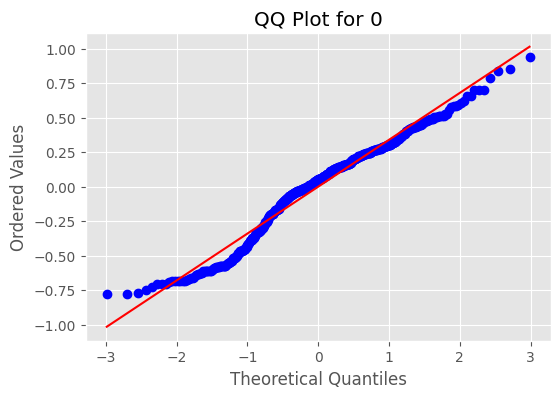

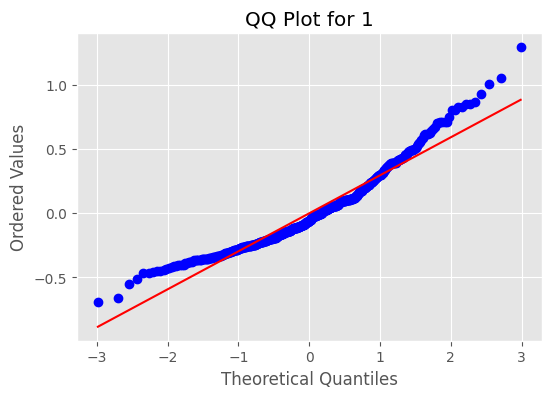

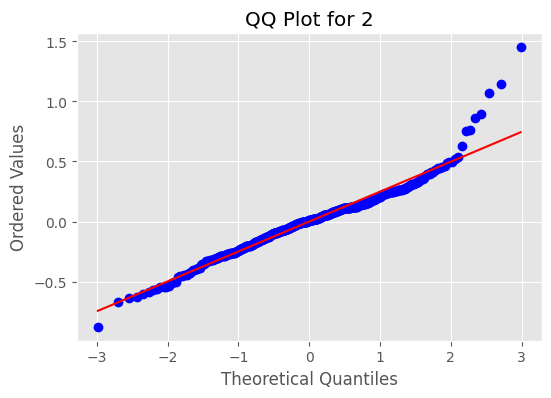

In [46]:
## checking for gaussian distributions using QQ-plots
for column in df_encoded_mca.columns:
    # Create QQ plot
    fig, ax = plt.subplots(figsize=(6, 4))
    stats.probplot(df_encoded_mca[column], dist='norm', plot=ax)
    
    # Set plot title and labels
    ax.set_title(f'QQ Plot for {column}')
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Ordered Values')
    
    # Show the plot
    plt.show()

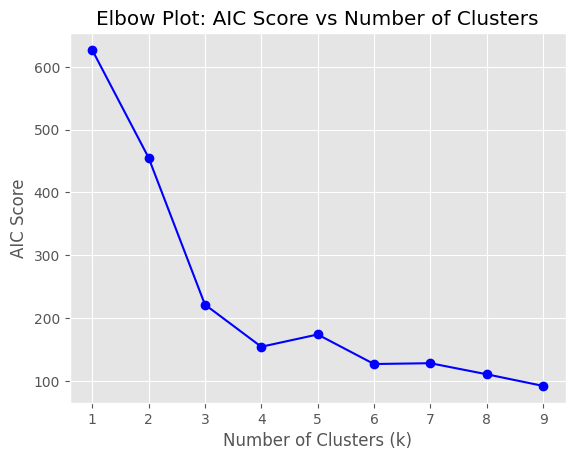

In [47]:
## Finding optimal number of clusters using the 
# Define the range of k values to test
k_values = range(1, 10)

# Initialize empty lists to store the BIC scores
aic_scores = []

# Calculate the BIC scores for different values of k
for k in k_values:
    gmm = GaussianMixture(n_components=k)
    gmm.fit(df_encoded_mca)
    aic_scores.append(gmm.aic(df_encoded_mca))

# Plot the elbow curve
plt.plot(k_values, aic_scores, marker='o', color="b")
plt.xlabel('Number of Clusters (k)')
plt.ylabel('AIC Score')
plt.title('Elbow Plot: AIC Score vs Number of Clusters')
plt.show()

In [48]:
# Define a range of values for n_init to try
n_init_values = [1, 3, 10, 30, 50, 75, 100, 200]
n_clusters_gmm = 2 # Specify the desired number of clusters

best_score = -1  # Initialize with a low value
best_n_init = None

"""
for n_init in n_init_values:
    # Create an instance of the GaussianMixture class with the desired parameters
    gmm = GaussianMixture(n_components=n_clusters_gmm, random_state=24, init_params="k-means++",
                          n_init=n_init, covariance_type="full")

    # Fit the data and obtain the cluster labels
    gmm.fit(df_encoded_mca)
    clusters_gmm = gmm.predict(df_encoded_mca)
    clusters_gmm = clusters_gmm + 1

    # Calculate the silhouette score
    silhouette_avg = silhouette_score(df_encoded_mca, clusters_gmm)
    
    # Check if the current silhouette score is better than the previous best
    if silhouette_avg > best_score:
        best_score = silhouette_avg
        best_n_init = n_init

# Print the best n_init and its corresponding silhouette score
print("Best n_init:", best_n_init)
print("Best Silhouette Score:", best_score)
"""

'\nfor n_init in n_init_values:\n    # Create an instance of the GaussianMixture class with the desired parameters\n    gmm = GaussianMixture(n_components=n_clusters_gmm, random_state=24, init_params="k-means++",\n                          n_init=n_init, covariance_type="full")\n\n    # Fit the data and obtain the cluster labels\n    gmm.fit(df_encoded_mca)\n    clusters_gmm = gmm.predict(df_encoded_mca)\n    clusters_gmm = clusters_gmm + 1\n\n    # Calculate the silhouette score\n    silhouette_avg = silhouette_score(df_encoded_mca, clusters_gmm)\n    \n    # Check if the current silhouette score is better than the previous best\n    if silhouette_avg > best_score:\n        best_score = silhouette_avg\n        best_n_init = n_init\n\n# Print the best n_init and its corresponding silhouette score\nprint("Best n_init:", best_n_init)\nprint("Best Silhouette Score:", best_score)\n'

In [49]:
# Create an instance of the GaussianMixture class
n_clusters_gmm = 3  # Specify the desired number of clusters
gmm = GaussianMixture(n_components=n_clusters_gmm, random_state=13, init_params='kmeans')
# Fit the data and obtain the cluster labels
gmm.fit(df_encoded_mca)
clusters_gmm = gmm.predict(df_encoded_mca)
clusters_gmm = clusters_gmm + 1

## Adding the labels to my original dataframe
df_analysis_final['Clusters_gmm'] = clusters_gmm

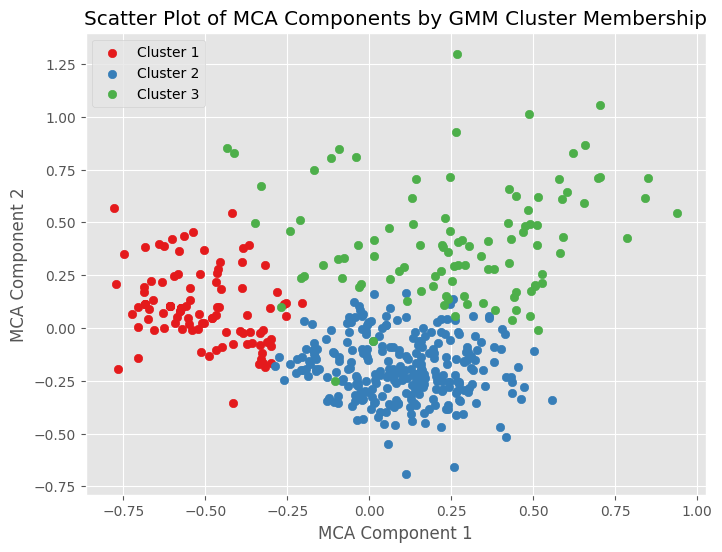

In [50]:
## MCA scatterplot
df_encoded_mca_gmm = df_encoded_mca.copy()
df_encoded_mca_gmm['Clusters_gmm'] = clusters_gmm
df_encoded_mca_gmm['Clusters_gmm'] = df_encoded_mca_gmm['Clusters_gmm'].astype('category')

# Extract the first two components from the MCA-transformed data
component_1 = df_encoded_mca_gmm.iloc[:, 0].values
component_2 = df_encoded_mca_gmm.iloc[:, 1].values

# Get the values from the fourth column for coloring
color_column = df_encoded_mca_gmm.iloc[:, 3].astype('category')  # Treat as categorical

# Create a scatter plot
plt.figure(figsize=(8, 6))

# Get seaborn color palette as list of RGB values
palette = sns.color_palette('Set1', len(color_column.cat.categories))

# Define colors for each category
categories = color_column.cat.categories
color_map = {category: color for category, color in zip(categories, palette)}  # Map categories to colors

# Plot each category separately with the corresponding color
for i, category in enumerate(categories):
    mask = color_column == category
    plt.scatter(component_1[mask], component_2[mask], color=color_map[category], label='Cluster {}'.format(category))

plt.xlabel('MCA Component 1')
plt.ylabel('MCA Component 2')
plt.title('Scatter Plot of MCA Components by GMM Cluster Membership')

# Add color keys for column labels
plt.legend(loc='upper left')
plt.show()

In [51]:
## Calculating silhouette score 
silhouette_avg_gmm = silhouette_score(df_encoded_mca, clusters_gmm)
print("Silhouette Score:", silhouette_avg_gmm)

Silhouette Score: 0.3716945565870248


In [52]:
## calculating the Calinski-Harabasz Index
ch_score = calinski_harabasz_score(df_encoded_mca, clusters_gmm)
print("Calinski-Harabasz Index:", ch_score)

Calinski-Harabasz Index: 244.96804474160908


In [53]:
# Calculate the Davies-Bouldin Index
dbi_score = davies_bouldin_score(df_encoded_mca, clusters_gmm)
print("Davies-Bouldin Index:", dbi_score)

Davies-Bouldin Index: 1.095087436036837


In [54]:
## getting feeling for size of clusters
unique_labels, cluster_sizes = np.unique(clusters_gmm, return_counts=True)

# Print the size of each cluster
for label, size in zip(unique_labels, cluster_sizes):
    print("Cluster {}: Size = {}".format(label, size))

Cluster 1: Size = 108
Cluster 2: Size = 279
Cluster 3: Size = 103


In [55]:
## Calculating AIC and BIC for GMM
aic = gmm.aic(df_encoded_mca)
bic = gmm.bic(df_encoded_mca)

print("AIC:", aic)
print("BIC:", bic)

AIC: 221.64814786570867
BIC: 343.2859042077441


## Section 3: Performance evaluation
This section will build the consensus clusters based on the three algorithms applied above in section 2.

In [56]:
## changing cluster labelling per algorithm
k_means_mapping = {1: 1, 2: 2, 3: 3}
hierarchical_mapping = {3: 1, 1: 2, 2: 3}
gmm_mapping = {3: 1, 2: 2, 1: 3}

corrected_k_means_labels = [k_means_mapping[label] for label in clusters_kmeans]
corrected_hierarchical_labels = [hierarchical_mapping[label] for label in final_hierarchical_clusters]
corrected_gmm_labels = [gmm_mapping[label] for label in clusters_gmm]

# Adding the corrected labels as new columns to the original DataFrame df_analysis_final
df_analysis_final['corrected_k_means_labels'] = corrected_k_means_labels
df_analysis_final['corrected_hierarchical_labels'] = corrected_hierarchical_labels
df_analysis_final['corrected_gmm_labels'] = corrected_gmm_labels

# Removing the older labels that are no longer correct
df_analysis_final.drop(columns=['Clusters_kmeans', 'Clusters_hierarchical', 'Clusters_gmm'], inplace=True)
df_analysis_final.head(3)

,age_category,sex,race,stage,bmi_category,marital_status,asbestos_exposure,alcohol_consumption,histology,molecular_alteration,packs_category,smoking_status,asbestosis,chronic_bronchitis,chronic_kidney_disease,depression,diabetes,emphysema,heart_failure,hypertension,inflammatory_bowel_disease,kidney_problems,liver_disease,myocardial infarction,pancreatic_disease,shortness_of_breath,stroke,survival_overall,packs_per_year,corrected_k_means_labels,corrected_hierarchical_labels,corrected_gmm_labels
0,70-79,Female,White/Caucasian,4,15-19.9,Single,No,No,Squamous cell carcinoma,EGFR-,50-59,ex-smoker,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,2.0,51.00,2,2,2
1,80-89,Female,White/Caucasian,1A,25-29.9,Single,No,No,Adenocarcinoma,EGFR-,10-19,ex-smoker,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,41.0,15.75,2,2,2
2,40-49,Female,White/Caucasian,4,20-24.9,Single,No,No,Adenocarcinoma,EGFR+,40-49,never-smoker,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,30.0,NaN,3,1,3


In [57]:
## Rand Score to check for label consistency
def calc_rand(kmeans, hierarchical, gmm):
    # Calculate the Adjusted Rand Index between k-means and hierarchical
    ari_kmeans_hierarchical = adjusted_rand_score(kmeans, hierarchical)

    # Calculate the Adjusted Rand Index between k-means and GMM
    ari_kmeans_gmm = adjusted_rand_score(kmeans, gmm)

    # Calculate the Adjusted Rand Index between hierarchical and GMM
    ari_hierarchical_gmm = adjusted_rand_score(hierarchical, gmm)

    print("Adjusted Rand Index (k-means vs. hierarchical):", ari_kmeans_hierarchical)
    print("Adjusted Rand Index (k-means vs. GMM):", ari_kmeans_gmm)
    print("Adjusted Rand Index (hierarchical vs. GMM):", ari_hierarchical_gmm)

calc_rand(clusters_kmeans, final_hierarchical_clusters, clusters_gmm)

Adjusted Rand Index (k-means vs. hierarchical): 0.636636778872159
Adjusted Rand Index (k-means vs. GMM): 0.8654050355064373
Adjusted Rand Index (hierarchical vs. GMM): 0.6400022282455334


In [58]:
## creating new analysis dataset to make changes on
df_analysis_final_consensus = df_analysis_final.copy()

df_analysis_final_consensus['type'] = df_analysis['label'].map(lambda x: 'small-cell' if x in ['SCLC late', 'SCLC early', 'Rare late'] else 'non-small-cell')
df_analysis_final_consensus['early_late'] = df_analysis['label'].map(lambda x: 'early stage' if x in ['NSLC early', 'SCLC early'] else 'late stage')

## adding a simpler stage variable (stage1-4)
df_analysis_final_consensus["stage_simple"] = df_analysis_final_consensus["stage"]
df_analysis_final_consensus.loc[df_analysis_final_consensus['stage_simple'].str.contains('1A|1B', na=False), 'stage_simple'] = 'I'
df_analysis_final_consensus.loc[df_analysis_final_consensus['stage_simple'].str.contains('2A|2B', na=False), 'stage_simple'] = 'II'
df_analysis_final_consensus.loc[df_analysis_final_consensus['stage_simple'].str.contains('3A|3B', na=False), 'stage_simple'] = 'III'
df_analysis_final_consensus.loc[df_analysis_final_consensus['stage_simple'].str.contains('4', na=False), 'stage_simple'] = 'IV'

## adding label back
df_analysis_final_consensus["label"] = df_analysis['label']

In [59]:
# Concatenate the cluster labels from K-means, hierarchical clustering, and GMM
all_clusters = np.column_stack((corrected_k_means_labels, corrected_hierarchical_labels, corrected_gmm_labels))

# Perform consensus clustering
consensus_clusters = []
n_clusters = np.max(all_clusters) + 1  # Number of clustering results

for i in range(all_clusters.shape[0]):
    cluster_counts = np.bincount(all_clusters[i], minlength=n_clusters)
    consensus_cluster = np.argmax(cluster_counts)
    consensus_clusters.append(consensus_cluster)

# Add the consensus cluster labels to the dataframe
df_analysis_final_consensus['consensus_clustering'] = consensus_clusters

## Adding the consensus column to the original dataset
df_analysis["consensus_clustering"] = df_analysis_final_consensus['consensus_clustering']

# Print the updated dataframe
df_analysis.head(4)

,patient_id,patient_status,survival,age,sex,race,occupation_years,marital_status,last_follow_up,alcohol_consumption,asbestos_exposure,health_status,height,histology,molecular_alteration,packs_per_year,smoking_status,stage,symptoms_past_week,weight,aids_hiv_positive,allergies,angina,angioplasty,arrythmia,asbestosis,barrett's_esophagus,cardiologist_visit,chronic_bronchitis,chronic_kidney_disease,coronary_artery_bypass_surgery,depression,diabetes,distant_recurrence,eczema,emphysema,gallstones,gastrointestinal_hemorrhage,gout,h_pylori_infection,heart_failure,heart_test,heartburn,heartburn_occurence,hepatitis,hepatitis_a,hepatitis_b,hepatitis_c,hepatitis_unknown,hiatus_hernia,hypertension,inflammatory_bowel_disease,jaundice,kidney_problems,liver_cirrhosis,liver_disease,local_recurrence,lupus_(sle),myocardial infarction,other_arthritis,palliative_progression,pancreatic_disease,peripheral_vascular_disease,pleural_plaques,pneumonia,regurgitation,rheumatoid_arthritis,shortness_of_breath,specific_drug_allergies,specific_kidney_problems,stomach_ulcer,stroke,transient_ischemic_attack,tuberculosis,aspirin_usage,nsaids_usage,curative_chemotherapy,curative_radiotherapy,curative_surgery,intent_of_care,palliative_chemotherapy,label,stage_simple,type,early_late,survival_overall,event_observed,BMI,age_category_old,age_category,packs_category_old,packs_category,bmi_category_old,bmi_category,consensus_clustering
0,TH2178,Dead,2.0,73.0,Female,White/Caucasian,18.0,Single,NaN,NaN,No,Fair,160.0,Squamous cell carcinoma,EGFR-,51.00,ex-smoker,4,In bed >50%,40.8,No,No,No,No,No,No,No,No,No,No,No,No,No,NaN,No,No,No,NaN,NaN,No,No,No,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,NaN,No,No,NaN,No,No,No,No,No,No,Yes,No,NaN,NaN,No,No,No,NaN,No,No,No,No,No,Palliative,No,NSLC late,4,non-small-cell,late stage,2.0,1,15.94,70-74,70-79,50-54,50-59,15-19,15-19.9,2
1,TH2392,Alive,NaN,81.0,Female,White/Caucasian,NaN,Single,41.0,No,No,Very Good,157.0,Adenocarcinoma,EGFR-,15.75,ex-smoker,1A,NaN,65.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,No,No,No,"Segmental resection, including lingulectomy",Curative,No,NSLC early,1,non-small-cell,early stage,41.0,0,26.65,80-84,80-89,15-19,10-19,25-29,25-29.9,2
2,TH4713,Dead,30.0,47.0,Female,NaN,NaN,NaN,29.0,NaN,NaN,NaN,NaN,Adenocarcinoma,EGFR+,NaN,never-smoker,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Metastatic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,No,No,Palliative,Osimertinib,NSLC late,4,non-small-cell,late stage,30.0,1,NaN,45-49,40-49,NaN,NaN,NaN,NaN,3
3,TH2276,Dead,16.0,71.0,Male,White/Caucasian,32.0,Single,NaN,No,No,Very Good,NaN,Small cell carcinoma,EGFR-,7.00,current-smoker,4,In bed >50%,62.1,No,No,No,No,No,No,No,No,No,No,No,No,No,NaN,No,No,No,No,NaN,No,No,No,Yes,NaN,No,No,No,No,No,No,No,Yes,No,No,No,No,NaN,No,No,NaN,Distant,No,No,No,No,Yes,No,No,NaN,NaN,No,No,No,NaN,No,No,No,No,No,Palliative,CDDP-VP16 or VP-P or VP16+DDP or CE,SCLC late,4,small-cell,late stage,16.0,1,NaN,70-74,70-79,5-9,0-9,NaN,NaN,2


In [60]:
## checking for disagreement across all three methods
all_clusters = np.column_stack((corrected_k_means_labels, corrected_hierarchical_labels, corrected_gmm_labels))
num_different_results = np.sum(np.all(np.diff(all_clusters, axis=1), axis=1))
print("Number of times all three algorithms have different results:", num_different_results)

Number of times all three algorithms have different results: 200


In [61]:
## checking the final sizes of the clusters
df_analysis_final_consensus['consensus_clustering'].value_counts()

consensus_clustering
2    286
3    111
1     93
Name: count, dtype: int64

### Chi Squared Test

In [62]:
## calculating chi squared values
def calculate_chi2_p_value(data, variable, cluster_variable='consensus_clustering'):
    # Create a contingency table
    contingency_table = data.groupby([cluster_variable, variable]).size().unstack().fillna(0)

    # Perform the Chi-square test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    return p

In [63]:
## pairwise comparisons - sex
def calculate_pairwise_chi2(data, variable, cluster_variable='consensus_clustering'):
    cluster_levels = data[cluster_variable].unique()
    cluster_pairs = list(combinations(cluster_levels, 2))

    p_values = {}
    for pair in cluster_pairs:
        sub_data = data[data[cluster_variable].isin(pair)]
        contingency_table = sub_data.groupby([cluster_variable, variable]).size().unstack().fillna(0)
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        p_values[pair] = p

    return p_values

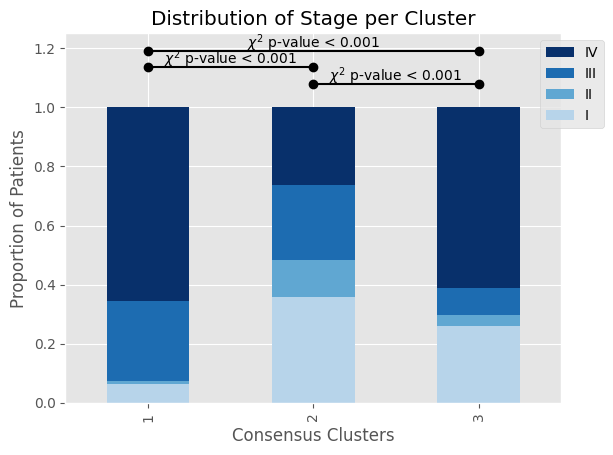

In [64]:
def create_stacked_bar_chart_one_color_with_significance(data, variable, title, legend_title):
   
    # Group the data by consensus_clustering and the specified variable, and count the number of occurrences
    grouped_data = data.groupby(['consensus_clustering', variable]).size().unstack()

    # Calculate the proportions by dividing each value by the sum in each cluster
    proportions = grouped_data.div(grouped_data.sum(axis=1), axis=0)

    # Set color palette
    category_order_stage = ['I', 'II', 'III', 'IV']
    colors = cm.Blues(np.linspace(0.3, 1, len(category_order_stage)))

    # Plot the stacked bar chart with the proportions
    ax = proportions[category_order_stage].plot(kind='bar', stacked=True, color=colors)

    # Set chart labels and title
    plt.xlabel('Consensus Clusters')
    plt.ylabel('Proportion of Patients')
    plt.title(title)

    # Reverse the order of handles and labels for the legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1], title=legend_title, loc='upper right', bbox_to_anchor=(1.1, 1))
    
    p_values = calculate_pairwise_chi2(data, variable)
    
    # Indicate significance
    for i, (pair, p_value) in enumerate(p_values.items()):
        if p_value < 0.05:  # Or use your desired threshold
            # Draw a line between the bars of the clusters
            ax.plot([pair[0] - 1, pair[1] - 1], [i/18 + 1.08, i/18 + 1.08], color='k', marker='o')
            # Annotate the line with '*'
            ax.text((pair[0] + pair[1])/2 - 1, i/18 + 1.09, '$\chi^2$ p-value < 0.001', ha='center')

    # Display the chart
    plt.show()

create_stacked_bar_chart_one_color_with_significance(df_analysis_final_consensus, 'stage_simple', 'Distribution of Stage per Cluster', '')

In [65]:
def categorize_packs(packs_bin):
    if packs_bin in ['0-9', '10-19']:
        return 'Lowest (<19)'
    elif packs_bin in ['20-29', '30-39', '40-49']:
        return 'Medium (20-49)'
    elif packs_bin in ['50-59', '60-69', '70-79']:
        return 'High (50-79)'
    elif packs_bin in ['80-89', '90-99']:
        return 'Very High (80-99)'
    else:  # This includes '100+'
        return 'Extreme (100+)'

df_analysis_final_consensus['packs_category_vis'] = df_analysis_final_consensus['packs_category'].apply(categorize_packs)

# Changing Packs function with correct label order
def create_stacked_bar_chart_packs(data, variable, title, legend_title):

    sns.set_palette("Set2")

    # Group the data by consensus_clustering and the specified variable, and count the number of occurrences
    grouped_data = df_analysis_final_consensus.groupby(['consensus_clustering', variable]).size().unstack()

    # Define the order of the categories
    category_order = ['Lowest (<19)', 'Medium (20-49)', 'High (50-79)', 'Very High (80-99)', 'Extreme (100+)']

    # Reorder the columns of the DataFrame according to the specified order
    grouped_data = grouped_data[category_order]

    # Calculate the proportions by dividing each value by the sum in each cluster
    proportions = grouped_data.div(grouped_data.sum(axis=1), axis=0)

    # Plot the stacked bar chart with the proportions
    ax = proportions.plot(kind='bar', stacked=True)

    # Set chart labels and title
    plt.xlabel('Consensus Clusters')
    plt.ylabel('Proportion of Patients')
    plt.title(title)

    # Reverse the order of handles and labels for the legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(reversed(handles), reversed(labels), title=legend_title, bbox_to_anchor=(1.2, 1), loc='upper right')

    # Display the chart
    plt.show()

In [66]:
## getting average age per cluster
df_analysis_final_consensus["age"] = df_analysis["age"]

# Impute missing values with the mean age
mean_age = df_analysis_final_consensus['age'].mean()
df_analysis_final_consensus['age'].fillna(mean_age, inplace=True)
average_age_per_cluster = df_analysis_final_consensus.groupby('consensus_clustering')['age'].mean()
print(average_age_per_cluster)

consensus_clustering
1    68.258065
2    67.902098
3    63.873874
Name: age, dtype: float64


In [67]:
## getting average packs smoked per cluster
mean_packs = df_analysis_final_consensus['packs_per_year'].mean()
df_analysis_final_consensus['packs_per_year'].fillna(mean_packs, inplace=True)
average_packs_per_cluster = df_analysis_final_consensus.groupby('consensus_clustering')['packs_per_year'].mean()
print(average_packs_per_cluster)

consensus_clustering
1    55.108315
2    41.957738
3    39.442140
Name: packs_per_year, dtype: float64


In [68]:
## getting average survival time per cluster
mean_survival = df_analysis_final_consensus['survival_overall'].mean()
df_analysis_final_consensus['survival_overall'].fillna(mean_survival, inplace=True)
average_survival_per_cluster = df_analysis_final_consensus.groupby('consensus_clustering')['survival_overall'].mean()
print(average_survival_per_cluster)

consensus_clustering
1    19.752688
2    49.227273
3    47.990991
Name: survival_overall, dtype: float64


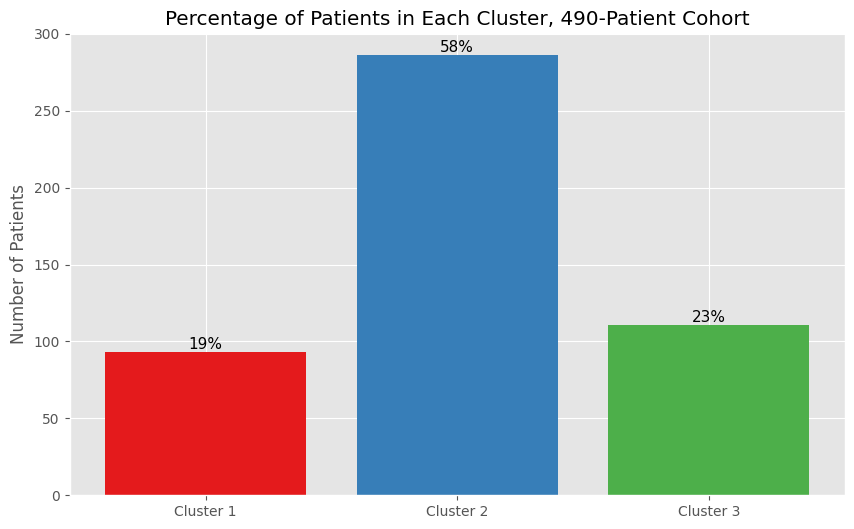

In [69]:
## building basic plot of cluster sizes
plt.style.use('ggplot')
cluster_counts = df_analysis_final_consensus['consensus_clustering'].value_counts().sort_index()
plt.figure(figsize=(10,6))

palette = sns.color_palette('Set1')[0:3]  # Adjust the index slice based on the number of clusters
bars = plt.bar(cluster_counts.index, cluster_counts.values, color=palette)

# Calculating the total number of patients
total_patients = cluster_counts.sum()

# Adding percentage labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    percentage = (yval / total_patients) * 100
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{percentage:.0f}%', ha='center', va='bottom', fontsize=11)

plt.ylabel('Number of Patients')
plt.title('Percentage of Patients in Each Cluster, 490-Patient Cohort')

# Adjusting x-ticks labels
cluster_labels = ['Cluster ' + str(i) for i in cluster_counts.index]
plt.xticks(cluster_counts.index, cluster_labels)
plt.show()

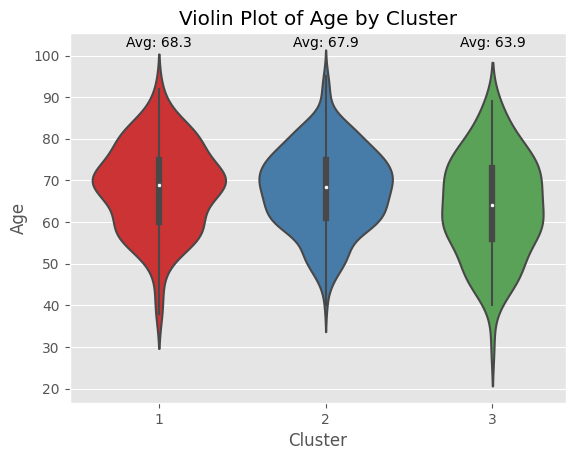

In [70]:
## violin plot showing average age
df_analysis_survival_new = df_analysis.sort_values('consensus_clustering')
palette = sns.color_palette('Set1')[0:3]  # Adjust the index slice based on the number of clusters
sns.violinplot(x='consensus_clustering', y='age', data=df_analysis_survival_new, palette=palette)

# Calculate mean ages for each cluster and plot them
cluster_means = df_analysis_survival_new.groupby('consensus_clustering')['age'].mean()
max_val = df_analysis_survival_new['age'].max() + 8  # the y position for text
for i in range(len(cluster_means)):
    plt.plot([i, i], [cluster_means[i+1], cluster_means[i+1]], 'r-', lw=2)
    plt.text(i, max_val, f'Avg: {cluster_means[i+1]:.1f}', ha='center', va='center', color='k')

plt.xlabel('Cluster')
plt.ylabel('Age')
plt.title('Violin Plot of Age by Cluster')
plt.show()

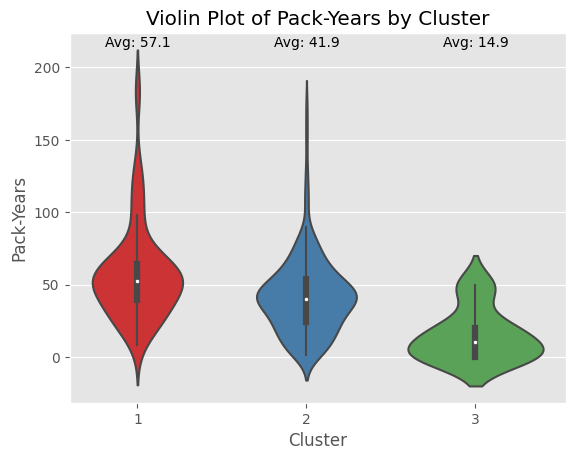

In [71]:
## violing plot showing average pack-years
df_analysis_survival_new = df_analysis_survival_new.sort_values('consensus_clustering')

palette = sns.color_palette('Set1')[0:3]  # Adjust the index slice based on the number of clusters

# Now, create the plot:
sns.violinplot(x='consensus_clustering', y='packs_per_year', data=df_analysis_survival_new, palette=palette)

# Calculate mean pack-years for each cluster and plot them
cluster_means = df_analysis_survival_new.groupby('consensus_clustering')['packs_per_year'].mean()
max_val = df_analysis_survival_new['packs_per_year'].max() + 32  # the y position for text
for i in range(len(cluster_means)):
    plt.plot([i, i], [cluster_means[i+1], cluster_means[i+1]], 'r-', lw=2)
    plt.text(i, max_val, f'Avg: {cluster_means[i+1]:.1f}', ha='center', va='center', color='k')

plt.xlabel('Cluster')
plt.ylabel('Pack-Years')
plt.title('Violin Plot of Pack-Years by Cluster')
plt.show()

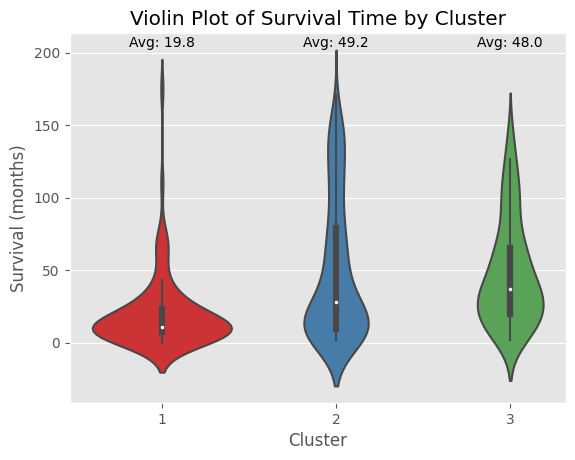

In [72]:
## violing plot showing average survival time
df_analysis_survival_new = df_analysis_survival_new.sort_values('consensus_clustering')
palette = sns.color_palette('Set1')[0:3]  # Adjust the index slice based on the number of clusters
sns.violinplot(x='consensus_clustering', y='survival_overall', data=df_analysis_survival_new, palette=palette)

# Calculate mean pack-years for each cluster and plot them
cluster_means = df_analysis_survival_new.groupby('consensus_clustering')['survival_overall'].mean()
max_val = df_analysis_survival_new['survival_overall'].max() + 32  # the y position for text
for i in range(len(cluster_means)):
    plt.plot([i, i], [cluster_means[i+1], cluster_means[i+1]], 'r-', lw=2)
    plt.text(i, max_val, f'Avg: {cluster_means[i+1]:.1f}', ha='center', va='center', color='k')

plt.xlabel('Cluster')
plt.ylabel('Survival (months)')
#plt.ylim(-50,250)
plt.title('Violin Plot of Survival Time by Cluster')
plt.show()

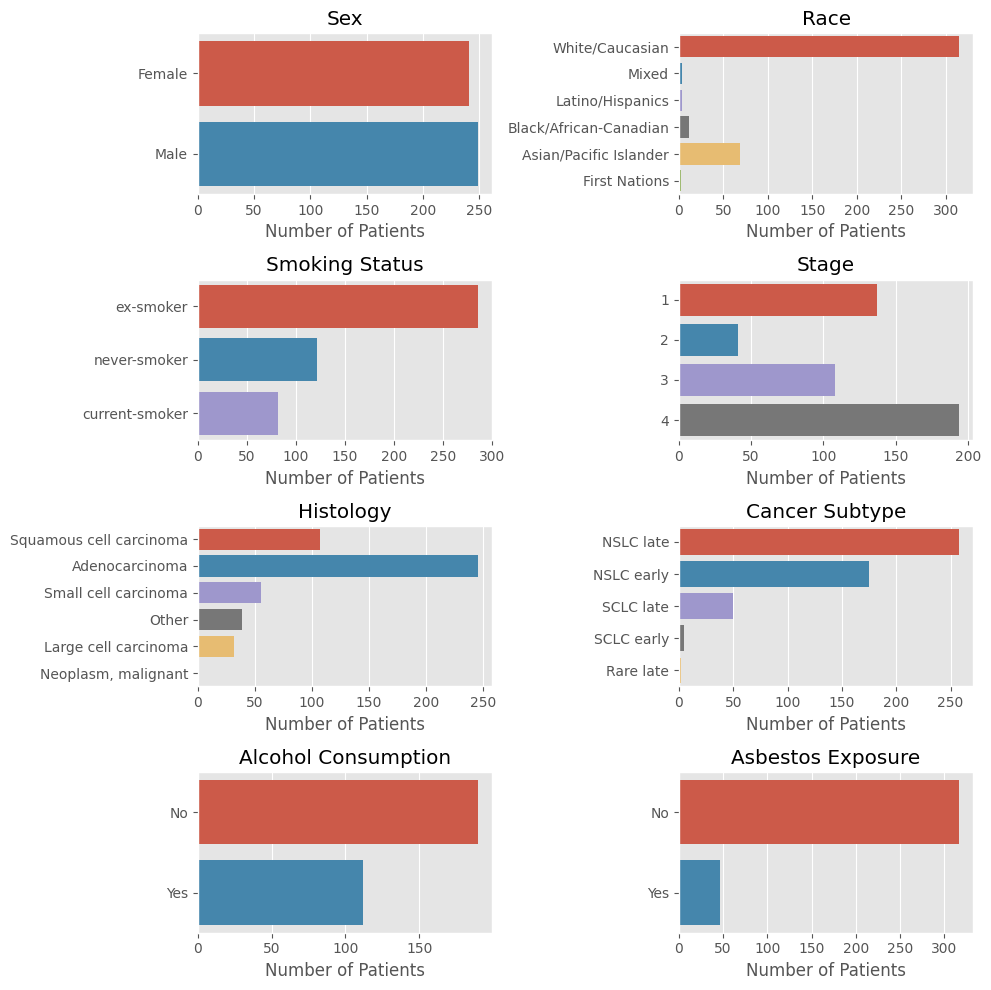

In [73]:
## EDA - looking at variable distribution
variables = df_analysis[["sex", "race", "smoking_status", "stage_simple", 
                         "histology", "label", "alcohol_consumption",
                         "asbestos_exposure"]]

titles = ["Sex", "Race", "Smoking Status", "Stage", 
          "Histology", "Cancer Subtype", "Alcohol Consumption", "Asbestos Exposure"]

fig, axes = plt.subplots(4, 2, figsize=(10, 10))  # Create a 2x4 grid of subplots

# Flatten the axes array to iterate over it
axes = axes.flatten()

# Iterate over each column, title, and ax
for column, title, ax in zip(variables, titles, axes):
    if column == 'stage_simple':
        sns.countplot(y=column, data=variables, order=sorted(variables[column].dropna().unique()), ax=ax)
    else:
        sns.countplot(y=column, data=variables, ax=ax)
    ax.set_ylabel('')  # Remove y-axis label
    ax.set_xlabel('Number of Patients')  # Set x-axis label
    ax.set_title(title)

plt.tight_layout()  # Ensure proper spacing between subplots
plt.show()


### Patient progression analysis

In [74]:
df_analysis["palliative_progression"].value_counts()

palliative_progression
Distant       75
No            67
Both          36
Metastatic    30
Local         27
Name: count, dtype: int64

In [75]:
## creating new progression dataframe with imputed variables - for chi squared test and cox regression

# imputed subset df - adding clustering, prognosis and survival info
df_analysis_progression = df_analysis_subset_imputed.copy()

## creating new data subset for under 5 years
df_analysis_progression['survival_overall'] = df_analysis['survival_overall']
df_analysis_progression['patient_status_5'] = df_analysis['patient_status']
df_analysis_progression.loc[df_analysis_progression['survival_overall'] > 60, 'patient_status_5'] = 'Alive'
subset_under5 = df_analysis_progression[df_analysis_progression['survival_overall'] < 60]
subset_under5['event_observed'] = (subset_under5['patient_status_5'] == 'Dead').astype(int)

## creating new data subset for under 8 years
df_analysis_progression['survival_overall'] = df_analysis['survival_overall']
df_analysis_progression['patient_status_8'] = df_analysis['patient_status']
df_analysis_progression.loc[df_analysis_progression['survival_overall'] > 96, 'patient_status_8'] = 'Alive'
subset_under8 = df_analysis_progression[df_analysis_progression['survival_overall'] < 96]
subset_under8['event_observed_8'] = (subset_under8['patient_status_8'] == 'Dead').astype(int)

## adding clustering labels
df_analysis_progression['consensus_clustering'] = df_analysis_final_consensus['consensus_clustering']

## adding stage_simple and type
df_analysis_progression['stage_simple'] = df_analysis_final_consensus['stage_simple']
df_analysis_progression['type'] = df_analysis_final_consensus['type']
df_analysis_progression['early_late'] = df_analysis_final_consensus['early_late']

# adding numeric feature and filling NaN values with the mean
df_analysis_progression['age'] = df_analysis['age']
#df_analysis_progression['age'] = df_analysis['age'].fillna(df_analysis['age'].mean())
df_analysis_progression['BMI'] = df_analysis['BMI']
#df_analysis_progression['BMI'] = df_analysis['BMI'].fillna(df_analysis['BMI'].mean())
df_analysis_progression['packs_per_year'] = df_analysis['packs_per_year']
#df_analysis_progression['packs_per_year'] = df_analysis['packs_per_year'].fillna(df_analysis['packs_per_year'].mean())

# adding progression variables
df_analysis_progression["distant_recurrence"] = df_analysis['distant_recurrence']
df_analysis_progression["local_recurrence"] = df_analysis['local_recurrence']
df_analysis_progression["palliative_progression"] = df_analysis['palliative_progression']
df_analysis_progression["palliative_chemotherapy"] = df_analysis['palliative_chemotherapy']
df_analysis_progression["curative_chemotherapy"] = df_analysis['curative_chemotherapy']
df_analysis_progression["curative_surgery"] = df_analysis['curative_surgery']
df_analysis_progression["curative_radiotherapy"] = df_analysis['curative_radiotherapy']
df_analysis_progression["intent_of_care"] = df_analysis['intent_of_care']

#distance recurrence
def recategorize(val):
    if pd.isna(val):  # Checks for NaN values
        return val
    elif val in ['Lung', 'Brain', 'Bone', 'Pleura', 'Liver']:
        return val
    else:
        return 'Other'

df_analysis_progression['distant_recurrence'] = df_analysis_progression['distant_recurrence'].map(recategorize)

#local recurrence
#column_index_of_local_recurrence = df_analysis_progression.columns.get_loc('local_recurrence')
#df_analysis_progression.iloc[:, column_index_of_local_recurrence] = df_analysis_progression.iloc[:, column_index_of_local_recurrence].fillna('missing')

#palliative progression
#column_index_of_palliative_progression = df_analysis_progression.columns.get_loc('palliative_progression')
#df_analysis_progression.iloc[:, column_index_of_palliative_progression] = df_analysis_progression.iloc[:, column_index_of_palliative_progression].fillna('missing')

#palliative chemotherapy
df_analysis_progression['palliative_chemotherapy'] = np.where((df_analysis_progression['palliative_chemotherapy'].notna()) & (df_analysis_progression['palliative_chemotherapy'] != 'No'), 'Yes', df_analysis_progression['palliative_chemotherapy'])
df_analysis_progression['palliative_chemotherapy'] = df_analysis_progression['palliative_chemotherapy'].fillna(df_analysis_progression['palliative_chemotherapy'].mode()[0])

# curative chemotherapy
df_analysis_progression['curative_chemotherapy'] = np.where((df_analysis_progression['curative_chemotherapy'].notna()) & (df_analysis_progression['curative_chemotherapy'] != 'No'), 'Yes', df_analysis_progression['curative_chemotherapy'])
df_analysis_progression['curative_chemotherapy'] = df_analysis_progression['curative_chemotherapy'].fillna(df_analysis_progression['curative_chemotherapy'].mode()[0])

# curative surgery
df_analysis_progression['curative_surgery'] = np.where((df_analysis_progression['curative_surgery'].notna()) & (df_analysis_progression['curative_surgery'] != 'No'), 'Yes', df_analysis_progression['curative_surgery'])

# curative radiotherapy
df_analysis_progression['curative_radiotherapy'] = np.where((df_analysis_progression['curative_radiotherapy'].notna()) & (df_analysis_progression['curative_radiotherapy'] != 'No'), 'Yes', df_analysis_progression['curative_radiotherapy'])
df_analysis_progression['curative_radiotherapy'] = df_analysis_progression['curative_radiotherapy'].fillna(df_analysis_progression['curative_radiotherapy'].mode()[0])

# intent of care
df_analysis_progression['intent_of_care'] = df_analysis_progression['intent_of_care'].fillna(df_analysis_progression['intent_of_care'].mode()[0])

## imputing numeric variables using regression
def impute_with_regression(df, column):
    # Create an IterativeImputer object
    imp = IterativeImputer(max_iter=10, random_state=0)

    # Make a copy of the DataFrame
    df_imputed = df.copy()

    # Perform the imputation on the specific column
    df_imputed[[column]] = imp.fit_transform(df[[column]])

    return df_imputed

# List of columns to be imputed
columns_to_impute = ['age', 'BMI', 'packs_per_year']

# Apply the function to each column
for column in columns_to_impute:
    df_analysis_progression = impute_with_regression(df_analysis_progression, column)

# Check if the missing values in the specified columns are imputed
for column in columns_to_impute:
    print(f"Missing values in {column}: {df_analysis_progression[column].isnull().sum()}")

df_analysis_progression.head()

Missing values in age: 0
Missing values in BMI: 0
Missing values in packs_per_year: 0


/tmp/ipykernel_1683/585513851.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_under5['event_observed'] = (subset_under5['patient_status_5'] == 'Dead').astype(int)
/tmp/ipykernel_1683/585513851.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_under8['event_observed_8'] = (subset_under8['patient_status_8'] == 'Dead').astype(int)


,age_category,sex,race,stage,bmi_category,marital_status,asbestos_exposure,alcohol_consumption,histology,molecular_alteration,packs_category,smoking_status,asbestosis,chronic_bronchitis,chronic_kidney_disease,depression,diabetes,emphysema,heart_failure,hypertension,inflammatory_bowel_disease,kidney_problems,liver_disease,myocardial infarction,pancreatic_disease,shortness_of_breath,stroke,survival_overall,patient_status_5,patient_status_8,consensus_clustering,stage_simple,type,early_late,age,BMI,packs_per_year,distant_recurrence,local_recurrence,palliative_progression,palliative_chemotherapy,curative_chemotherapy,curative_surgery,curative_radiotherapy,intent_of_care
0,70-79,Female,White/Caucasian,4,15-19.9,Single,No,No,Squamous cell carcinoma,EGFR-,50-59,ex-smoker,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,2.0,Dead,Dead,2,IV,non-small-cell,late stage,73.0,15.940000,51.000000,NaN,NaN,No,No,No,No,No,Palliative
1,80-89,Female,White/Caucasian,1A,25-29.9,Single,No,No,Adenocarcinoma,EGFR-,10-19,ex-smoker,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,41.0,Alive,Alive,2,I,non-small-cell,early stage,81.0,26.650000,15.750000,NaN,NaN,NaN,No,No,Yes,No,Curative
2,40-49,Female,White/Caucasian,4,20-24.9,Single,No,No,Adenocarcinoma,EGFR+,40-49,never-smoker,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,30.0,Dead,Dead,3,IV,non-small-cell,late stage,47.0,24.960437,43.883804,NaN,NaN,Metastatic,Yes,No,No,No,Palliative
3,70-79,Male,White/Caucasian,4,20-24.9,Single,No,No,Small cell carcinoma,EGFR-,0-9,current-smoker,No,No,No,No,No,No,No,No,Yes,No,No,No,No,No,No,16.0,Dead,Dead,2,IV,small-cell,late stage,71.0,24.960437,7.000000,NaN,NaN,Distant,Yes,No,No,No,Palliative
4,80-89,Female,Mixed,1A,25-29.9,Divorced,No,Yes,Adenocarcinoma,EGFR-,0-9,ex-smoker,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,35.0,Dead,Dead,2,I,non-small-cell,early stage,82.0,26.210000,6.500000,NaN,NaN,NaN,No,No,No,Yes,Curative


In [76]:
## original df without imputation...
## making most post-diagnosis variables binary
## creating new data subset for under 5 years
df_analysis['patient_status_5'] = df_analysis['patient_status']
df_analysis.loc[df_analysis['survival_overall'] > 60, 'patient_status_5'] = 'Alive'
subset_under5 = df_analysis[df_analysis['survival_overall'] < 60]
subset_under5['event_observed'] = (subset_under5['patient_status_5'] == 'Dead').astype(int)

## creating new data subset for under 8 years
df_analysis['patient_status_8'] = df_analysis['patient_status']
df_analysis.loc[df_analysis['survival_overall'] > 96, 'patient_status_8'] = 'Alive'
subset_under8 = df_analysis[df_analysis['survival_overall'] < 96]
subset_under8['event_observed_8'] = (subset_under8['patient_status_8'] == 'Dead').astype(int)

## adding clustering labels
df_analysis["consensus_clustering"] = df_analysis_final_consensus["consensus_clustering"]

## adding 0 packs for never smokers 
df_analysis.loc[df_analysis['smoking_status'] == 'never smoker', 'packs_category'].fillna(0, inplace=True)
#distance recurrence
#df_analysis_survival['distant_recurrence'] = df_analysis_survival['distant_recurrence'].fillna('no')
#df_analysis_survival['distant_recurrence'] = df_analysis_survival['distant_recurrence'].map(lambda x: 'yes' if x != 'no' else x)
def recategorize(val):
    if pd.isna(val):  # Checks for NaN values
        return 'No'
    elif val in ['Lung', 'Brain', 'Bone', 'Pleura', 'Liver']:
        return val
    else:
        return 'Other'

df_analysis['distant_recurrence'] = df_analysis['distant_recurrence'].map(recategorize)

#local recurrence
#column_index_of_local_recurrence = df_analysis.columns.get_loc('local_recurrence')
#df_analysis.iloc[:, column_index_of_local_recurrence] = df_analysis.iloc[:, column_index_of_local_recurrence].fillna('missing')

#palliative progression
column_index_of_palliative_progression = df_analysis.columns.get_loc('palliative_progression')
df_analysis.iloc[:, column_index_of_palliative_progression] = df_analysis.iloc[:, column_index_of_palliative_progression].fillna('missing')

#palliative chemotherapy
df_analysis['palliative_chemotherapy'] = np.where((df_analysis['palliative_chemotherapy'].notna()) & (df_analysis['palliative_chemotherapy'] != 'No'), 'Yes', df_analysis['palliative_chemotherapy'])

# curative chemotherapy
df_analysis['curative_chemotherapy'] = np.where((df_analysis['curative_chemotherapy'].notna()) & (df_analysis['curative_chemotherapy'] != 'No'), 'Yes', df_analysis['curative_chemotherapy'])

# curative surgery
df_analysis['curative_surgery'] = np.where((df_analysis['curative_surgery'].notna()) & (df_analysis['curative_surgery'] != 'No'), 'Yes', df_analysis['curative_surgery'])

# curative radiotherapy
df_analysis['curative_radiotherapy'] = np.where((df_analysis['curative_radiotherapy'].notna()) & (df_analysis['curative_radiotherapy'] != 'No'), 'Yes', df_analysis['curative_radiotherapy'])

df_anaysis_survival = df_analysis.copy()

/tmp/ipykernel_1683/3370572573.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_under5['event_observed'] = (subset_under5['patient_status_5'] == 'Dead').astype(int)
/tmp/ipykernel_1683/3370572573.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_under8['event_observed_8'] = (subset_under8['patient_status_8'] == 'Dead').astype(int)


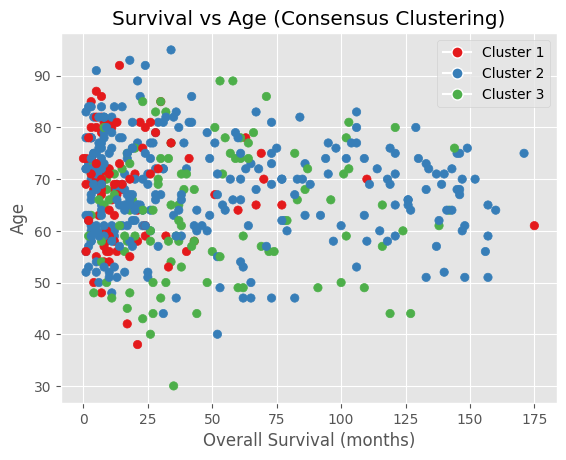

In [77]:
## scatter plot showing cluster membership
palette = sns.color_palette('Set1', np.unique(df_analysis_progression["consensus_clustering"]).shape[0])
color_map = {label: color for label, color in zip(np.unique(df_analysis_progression["consensus_clustering"]), palette)}
colors = df_analysis_progression["consensus_clustering"].map(color_map)

# Draw the scatterplot with the specified colors
scatter = plt.scatter(df_analysis_progression['survival_overall'], df_analysis_progression['age'], c=colors)
plt.xlabel('Overall Survival (months)')
plt.ylabel('Age')
plt.title('Survival vs Age (Consensus Clustering)')

# Add a legend with the correct colors
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[i], markersize=8)
                   for i in color_map.keys()]
cluster_labels_kmeans = ['Cluster {}'.format(i) for i in color_map.keys()]
plt.legend(legend_elements, cluster_labels_kmeans)

plt.show()


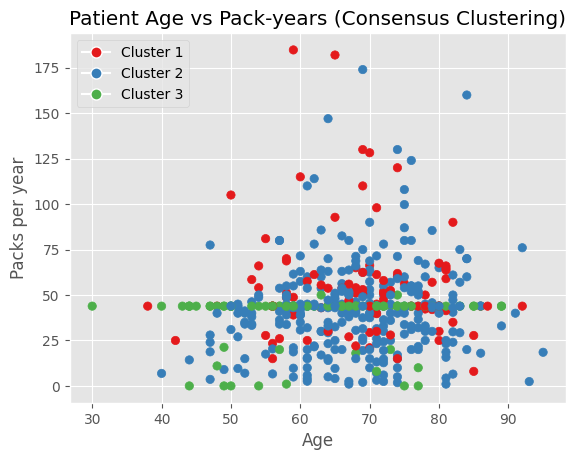

In [78]:
## scatter plot showing cluster membership
# Get seaborn color palette as list of RGB values
palette = sns.color_palette('Set1', np.unique(df_analysis_progression["consensus_clustering"]).shape[0])
color_map = {label: color for label, color in zip(np.unique(df_analysis_progression["consensus_clustering"]), palette)}
colors = df_analysis_progression["consensus_clustering"].map(color_map)

# Draw the scatterplot with the specified colors
scatter = plt.scatter(df_analysis_progression['age'], df_analysis_progression['packs_per_year'], c=colors)
plt.xlabel('Age')
plt.ylabel('Packs per year')
plt.title('Patient Age vs Pack-years (Consensus Clustering)')

# Limit the x-axis to 5 years
#plt.xlim(0, 60)

# Add a legend with the correct colors
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[i], markersize=8)
                   for i in color_map.keys()]
cluster_labels_kmeans = ['Cluster {}'.format(i) for i in color_map.keys()]
plt.legend(legend_elements, cluster_labels_kmeans)

plt.show()


In [79]:
## looking at the characteristics of cluster 3 non EGFR+ patients
# selecting 
df_analysis_progression.head()
selected_patients = df_analysis_progression[(df_analysis_progression['consensus_clustering'] == 3) & 
                                            (df_analysis_progression['molecular_alteration'] == "EGFR-")]

#print(len(selected_patients))
selected_patients.head()

,age_category,sex,race,stage,bmi_category,marital_status,asbestos_exposure,alcohol_consumption,histology,molecular_alteration,packs_category,smoking_status,asbestosis,chronic_bronchitis,chronic_kidney_disease,depression,diabetes,emphysema,heart_failure,hypertension,inflammatory_bowel_disease,kidney_problems,liver_disease,myocardial infarction,pancreatic_disease,shortness_of_breath,stroke,survival_overall,patient_status_5,patient_status_8,consensus_clustering,stage_simple,type,early_late,age,BMI,packs_per_year,distant_recurrence,local_recurrence,palliative_progression,palliative_chemotherapy,curative_chemotherapy,curative_surgery,curative_radiotherapy,intent_of_care
13,70-79,Female,White/Caucasian,4,20-24.9,Single,No,No,Small cell carcinoma,EGFR-,40-49,never-smoker,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,3.0,Alive,Alive,3,IV,small-cell,late stage,71.0,24.960437,43.883804,NaN,NaN,Both,Yes,No,No,No,Palliative
69,40-49,Male,White/Caucasian,4,25-29.9,Married or living with partner,Yes,No,Adenocarcinoma,EGFR-,40-49,never-smoker,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,17.0,Dead,Dead,3,IV,non-small-cell,late stage,45.0,25.320000,43.883804,NaN,NaN,Both,Yes,No,No,No,Palliative
119,60-69,Female,White/Caucasian,1A,25-29.9,Single,No,No,Adenocarcinoma,EGFR-,40-49,never-smoker,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,138.0,Alive,Alive,3,I,non-small-cell,early stage,61.0,26.080000,43.883804,NaN,NaN,NaN,No,No,Yes,No,Curative
134,80-89,Female,White/Caucasian,1A,20-24.9,Widowed,No,No,Adenocarcinoma,EGFR-,40-49,never-smoker,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,53.0,Alive,Alive,3,I,non-small-cell,early stage,89.0,24.890000,43.883804,NaN,NaN,NaN,No,No,Yes,No,Curative
174,70-79,Female,White/Caucasian,1A,25-29.9,Widowed,No,No,Adenocarcinoma,EGFR-,40-49,never-smoker,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,121.0,Alive,Alive,3,I,non-small-cell,early stage,80.0,27.290000,43.883804,NaN,NaN,NaN,No,No,Yes,No,Curative


In [80]:
## looking at sub-population of cluster 3 EGFR- patients
print(selected_patients['sex'].value_counts(normalize=True) * 100)
print(selected_patients['stage_simple'].value_counts(normalize=True) * 100)
print(selected_patients['race'].value_counts(normalize=True) * 100)
print(selected_patients['smoking_status'].value_counts(normalize=True) * 100)
print(selected_patients['histology'].value_counts(normalize=True) * 100)

#looking at average numeric features
print("age:", selected_patients['age'].mean())
print("BMI:", selected_patients['BMI'].mean())
print("packs_per_year:", selected_patients['packs_per_year'].mean())
print("survival_overall:", selected_patients['survival_overall'].mean())

sex
Female    86.956522
Male      13.043478
Name: proportion, dtype: float64
stage_simple
I      47.826087
IV     39.130435
III    13.043478
Name: proportion, dtype: float64
race
White/Caucasian           52.173913
Asian/Pacific Islander    39.130435
Black/African-Canadian     8.695652
Name: proportion, dtype: float64
smoking_status
never-smoker      95.652174
current-smoker     4.347826
Name: proportion, dtype: float64
histology
Adenocarcinoma             73.913043
Squamous cell carcinoma    13.043478
Other                       8.695652
Small cell carcinoma        4.347826
Name: proportion, dtype: float64
age: 63.52173913043478
BMI: 23.859244476122598
packs_per_year: 41.96999474053295
survival_overall: 52.65217391304348


## Survival analysis

In [81]:
## survival plot for different cluster associations
def survival_by_cluster(category, title):
    sns.set_palette("Set1")

    # Calculate the survival probabilities over time for each category
    time_months = np.arange(0, 61)  # Only consider the first 60 months (5 years)
    survival_probabilities = []
    labels = []

    plt.figure(figsize=(8, 5))
    lines = []  # To store the line objects
    
    for category_value in sorted(df_analysis[category].dropna().unique()):
        data = df_analysis[(df_analysis[category] == category_value) & ~df_analysis[category].isna()]
        survival_probability = []

        for time in range(61):  # Step 2: Iterate up to 60 months
            if time > 60:  # Step 3: Mark patients who die after 60 months as alive
                num_alive = len(data)  # All patients are marked as alive
            else:
                num_alive = len(data[data['survival_overall'] > time])

            num_total = len(data)
            if num_total != 0:
                survival_probability.append(num_alive / num_total * 100)
            else:
                survival_probability.append(0)  # Append 0 when no patients are present

        # Only add the category if it has non-zero survival probabilities
        if len(survival_probability) > 0:
            survival_probabilities.append(survival_probability)
            labels.append(category_value)

            # Plot the lines and collect the line objects
            line, = plt.plot(time_months[:len(survival_probability)], survival_probability, label=category_value)
            lines.append(line)

    for i, category_value in enumerate(labels):
        line_color = lines[i].get_color()  # Get the color of the line

        # Add markers for censored patients
        censored_data = df_analysis[(df_analysis[category] == category_value) &
                                         (df_analysis['patient_status_5'] == 'Alive') &
                                         (df_analysis['survival_overall'] <= 60)]  # Exclude patients who died after 60 months
        censored_times = censored_data['survival_overall'].astype(int)
        censored_probabilities = [survival_probabilities[i][t] for t in censored_times]

        plt.plot(censored_times, censored_probabilities, '|', color=line_color, markersize=6, mew=2)

    # Set labels and title
    plt.xlabel('Time (Months)')
    plt.ylabel('Percentage of Patients Alive')
    plt.title(title, fontsize=16)
    plt.legend()

    # Perform the log-rank test  
    results = multivariate_logrank_test(subset_under5['survival_overall'], subset_under5[category], 
                                        subset_under5['event_observed'])

    p_value = results.p_value

    # Display the p-value in the legend
    p_value_str = "<0.001" if p_value < 0.001 else f"{p_value:.4f}"
    plt.legend(title=f"P-Value: {p_value_str}")
    plt.show

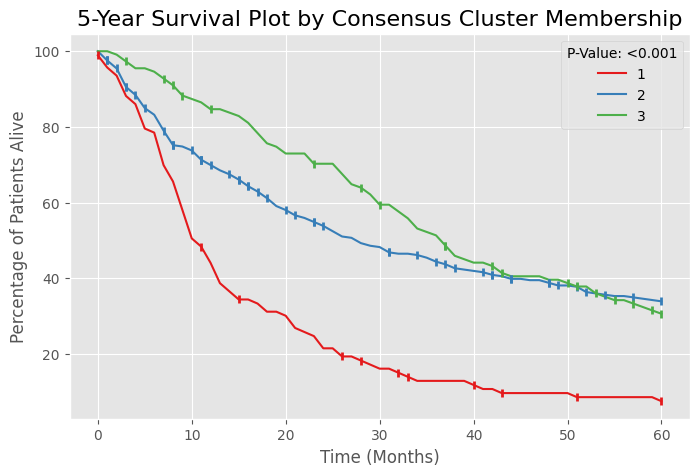

In [82]:
survival_by_cluster("consensus_clustering", "5-Year Survival Plot by Consensus Cluster Membership")

In [83]:
#plt.style.use('default')
plt.style.use('ggplot')

In [84]:
"""
survival_by_cluster("stage_simple", "Survival Probability by Cancer Stage")
"""

'\nsurvival_by_cluster("stage_simple", "Survival Probability by Cancer Stage")\n'

## Chi Squared test

In [85]:
df_analysis_progression.head(3)

,age_category,sex,race,stage,bmi_category,marital_status,asbestos_exposure,alcohol_consumption,histology,molecular_alteration,packs_category,smoking_status,asbestosis,chronic_bronchitis,chronic_kidney_disease,depression,diabetes,emphysema,heart_failure,hypertension,inflammatory_bowel_disease,kidney_problems,liver_disease,myocardial infarction,pancreatic_disease,shortness_of_breath,stroke,survival_overall,patient_status_5,patient_status_8,consensus_clustering,stage_simple,type,early_late,age,BMI,packs_per_year,distant_recurrence,local_recurrence,palliative_progression,palliative_chemotherapy,curative_chemotherapy,curative_surgery,curative_radiotherapy,intent_of_care
0,70-79,Female,White/Caucasian,4,15-19.9,Single,No,No,Squamous cell carcinoma,EGFR-,50-59,ex-smoker,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,2.0,Dead,Dead,2,IV,non-small-cell,late stage,73.0,15.940000,51.000000,NaN,NaN,No,No,No,No,No,Palliative
1,80-89,Female,White/Caucasian,1A,25-29.9,Single,No,No,Adenocarcinoma,EGFR-,10-19,ex-smoker,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,41.0,Alive,Alive,2,I,non-small-cell,early stage,81.0,26.650000,15.750000,NaN,NaN,NaN,No,No,Yes,No,Curative
2,40-49,Female,White/Caucasian,4,20-24.9,Single,No,No,Adenocarcinoma,EGFR+,40-49,never-smoker,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,30.0,Dead,Dead,3,IV,non-small-cell,late stage,47.0,24.960437,43.883804,NaN,NaN,Metastatic,Yes,No,No,No,Palliative


In [86]:
# Your list of variables
relevant_columns_progression = ['age_category','sex', 'race', 'stage', 'bmi_category',
                        'asbestos_exposure', "alcohol_consumption", 'histology', 
                        'molecular_alteration', 'smoking_status', 'packs_category', 'asbestosis', 
                        'chronic_bronchitis','emphysema', 'shortness_of_breath',
                        'depression','diabetes', 'hypertension','chronic_kidney_disease',
                        'kidney_problems', 'liver_disease', 'heart_failure','inflammatory_bowel_disease',
                        'myocardial infarction', 'palliative_progression', 'stroke', 'pancreatic_disease',
                        'distant_recurrence', 'local_recurrence', 'palliative_chemotherapy',
                        'intent_of_care','curative_surgery','curative_radiotherapy','curative_chemotherapy']

# Calculate the p-values for each variable
p_values = {variable: calculate_chi2_p_value(df_analysis_progression, variable) for variable in relevant_columns_progression}

# Sort the dictionary items by their values (i.e., p-values), in ascending order
sorted_p_values = sorted(p_values.items(), key=lambda item: item[1])

# Calculate the Bonferroni corrected alpha
bonferroni_alpha = 0.05 / len(relevant_columns_progression)

# Now compare each p-value to your adjusted significance level
significant_variables = [variable for variable, p_value in sorted_p_values if p_value < bonferroni_alpha]

print(f"Variables that are significantly associated with cluster membership at the Bonferroni corrected alpha level of {bonferroni_alpha} are:")
for variable in significant_variables:
    print(variable)

'''
# Print the sorted p-values
for variable, p_value in sorted_p_values:
    print(f"{variable}: {p_value}")
'''

Variables that are significantly associated with cluster membership at the Bonferroni corrected alpha level of 0.0014705882352941176 are:
smoking_status
molecular_alteration
packs_category
hypertension
shortness_of_breath
chronic_bronchitis
diabetes
intent_of_care
palliative_chemotherapy
histology
sex
stage
race
myocardial infarction
curative_surgery
depression
palliative_progression
emphysema
alcohol_consumption
stroke
curative_radiotherapy
heart_failure
age_category
kidney_problems


'\n# Print the sorted p-values\nfor variable, p_value in sorted_p_values:\n    print(f"{variable}: {p_value}")\n'

In [87]:
# For 'sex' variable
sex_p_values = calculate_pairwise_chi2(df_analysis_progression, 'sex')

# Print the p-values for each pair of clusters
for pair, p_value in sex_p_values.items():
    print(f"Clusters {pair[0]} and {pair[1]}: {p_value}")

Clusters 2 and 3: 7.776827832151048e-16
Clusters 2 and 1: 0.5931841205613397
Clusters 3 and 1: 1.1849501679755653e-09


In [88]:
# For 'molecular alteration' variable
egfr_p_values = calculate_pairwise_chi2(df_analysis_progression, 'molecular_alteration')

# Print the p-values for each pair of clusters
for pair, p_value in egfr_p_values.items():
    print(f"Clusters {pair[0]} and {pair[1]}: {p_value}")

Clusters 2 and 3: 3.479244383026988e-49
Clusters 2 and 1: 0.4523118976197058
Clusters 3 and 1: 6.4409086137518444e-27


In [89]:
# For 'pack-years' variable
packs_p_values = calculate_pairwise_chi2(df_analysis_progression, 'packs_category')

# Print the p-values for each pair of clusters
for pair, p_value in packs_p_values.items():
    print(f"Clusters {pair[0]} and {pair[1]}: {p_value}")

Clusters 2 and 3: 6.778901765671437e-30
Clusters 2 and 1: 1.8997825997214868e-07
Clusters 3 and 1: 1.1636715410896291e-18


In [90]:
## making sure categories are in right order
age_labels = ['under 40', '40-49', '50-59', '60-69', '70-79', '80-89', '90+']
df_analysis_progression['age_category'] = pd.Categorical(df_analysis_progression['age_category'], categories=age_labels, ordered=True)

packs_labels = ['0-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89', '90-99', '100+']
df_analysis_progression['packs_category'] = pd.Categorical(df_analysis_progression['packs_category'], categories=packs_labels, ordered=True)

#remapping categorical variables
def remap_categories(value, detailed_labels, broad_labels):
    for i in range(0, len(detailed_labels), 2):  # we step by 2 as you mentioned 2 detailed bins map to 1 broad bin
        if value in detailed_labels[i:i+2]:
            return broad_labels[i//2]  # we divide by 2 as two detailed bins map to one broad bin
    return value  # return original value if it doesn't match any bin

df_analysis_progression['age_category_broad'] = df_analysis_progression['age_category'].apply(
    lambda x: remap_categories(x, age_labels_model, age_labels))

df_analysis_progression['packs_category_broad'] = df_analysis_progression['packs_category'].apply(
    lambda x: remap_categories(x, packs_labels_model, packs_labels))

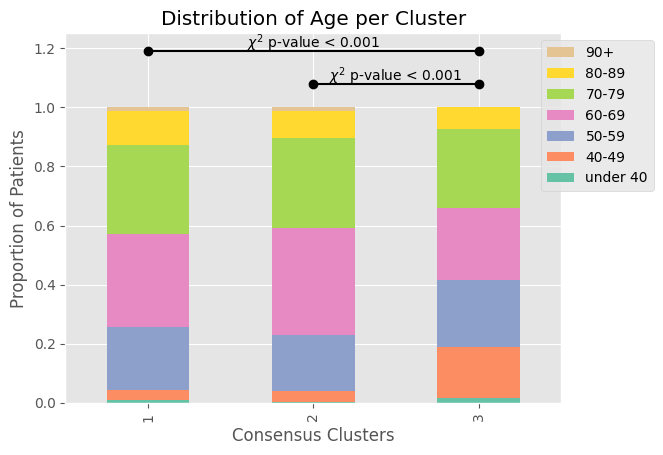

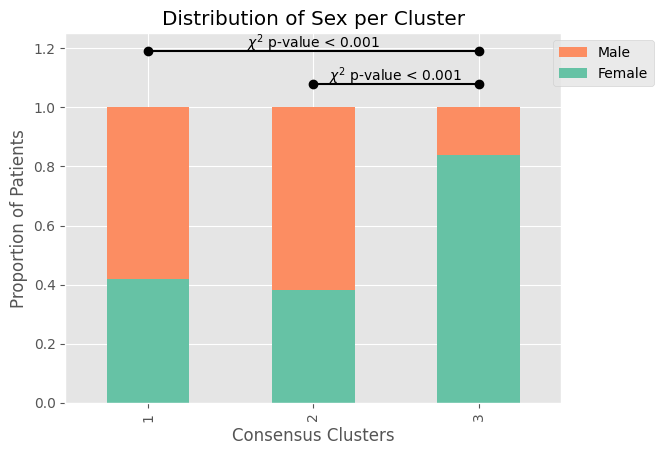

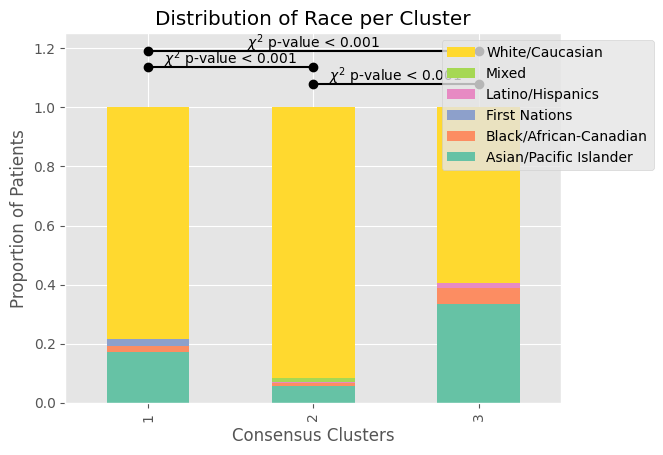

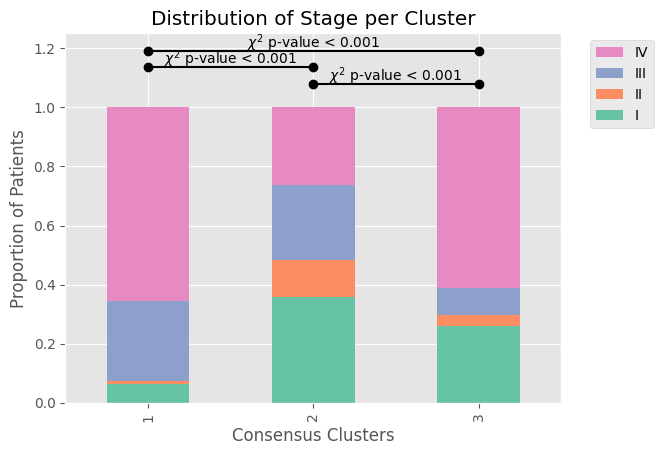

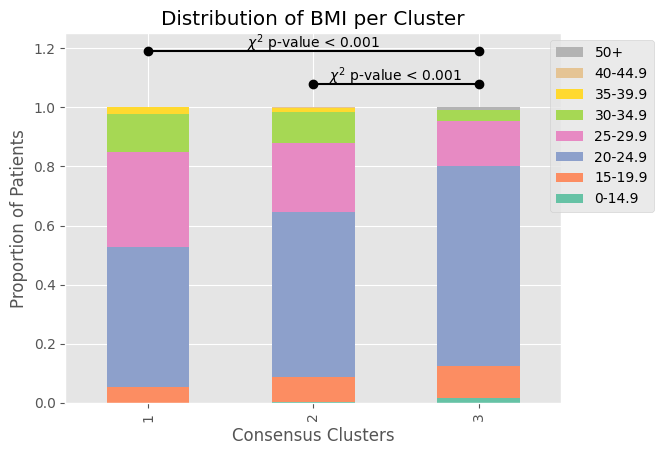

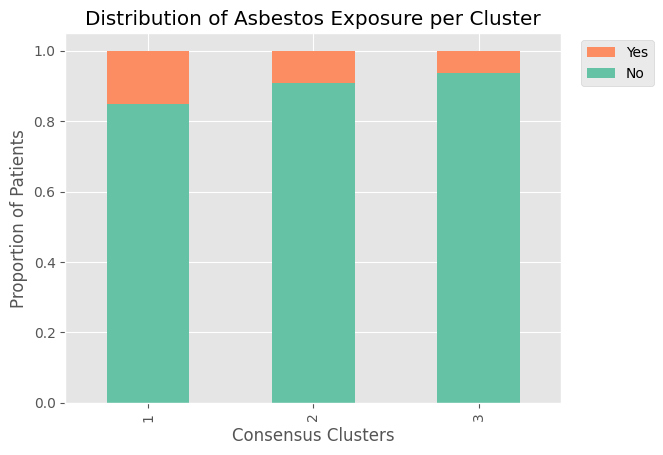

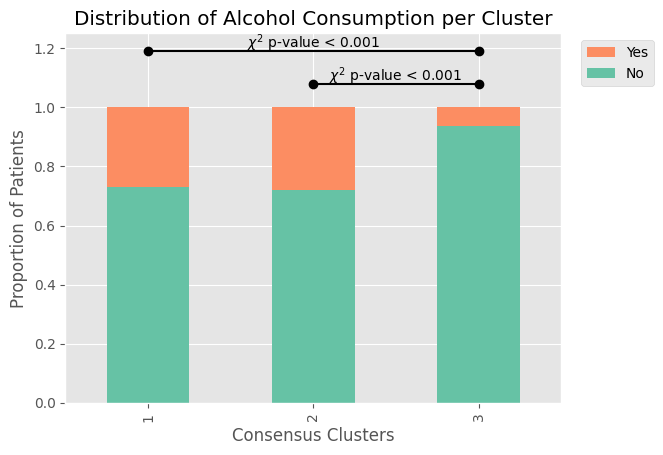

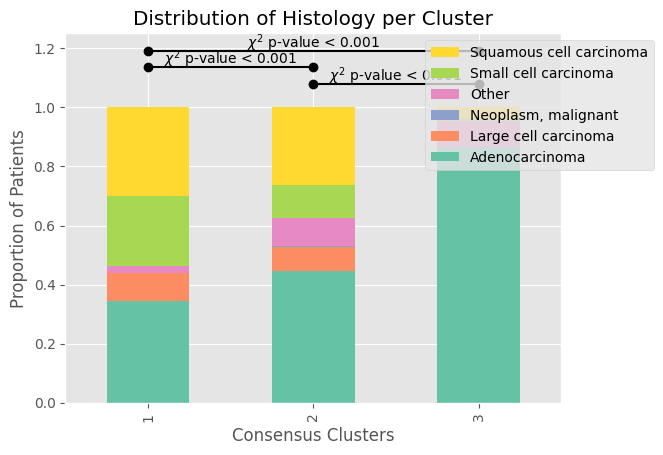

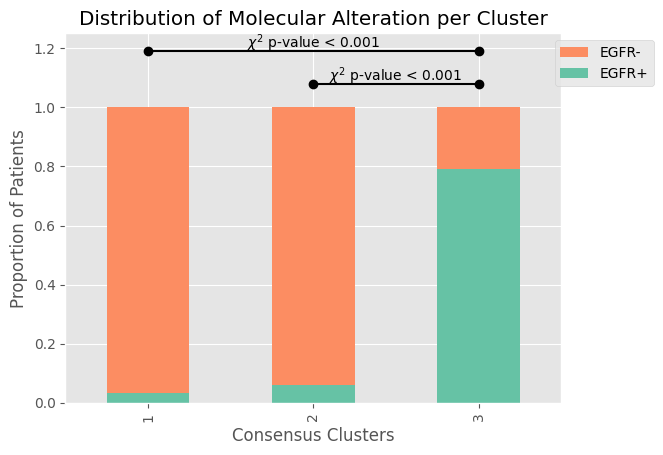

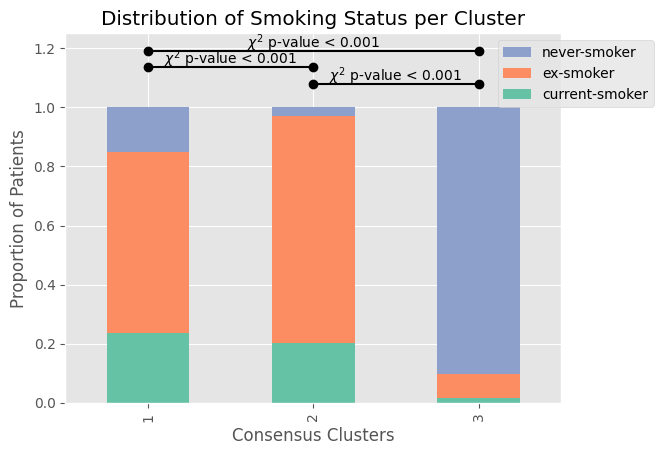

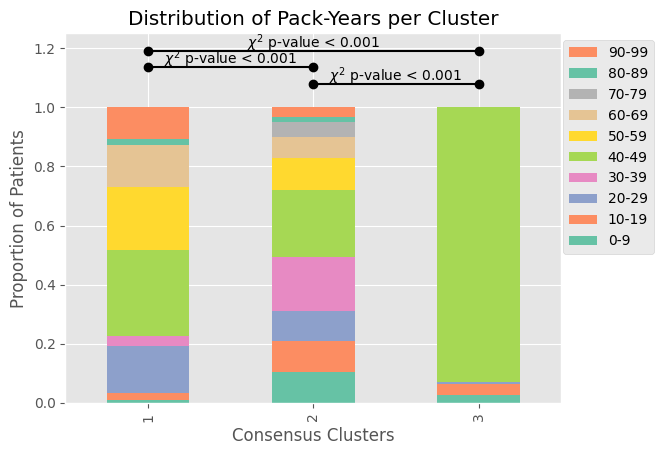

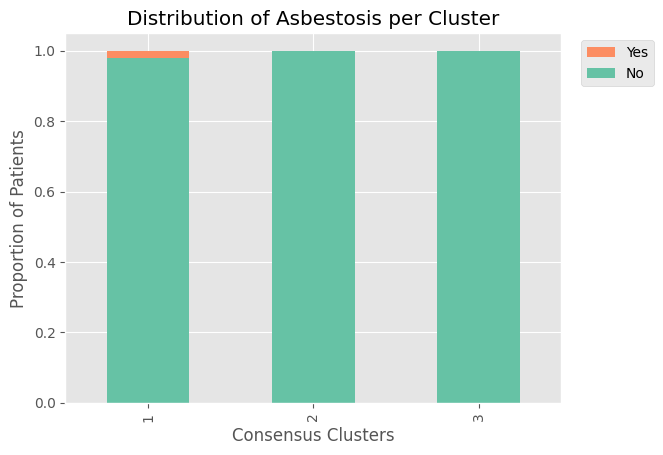

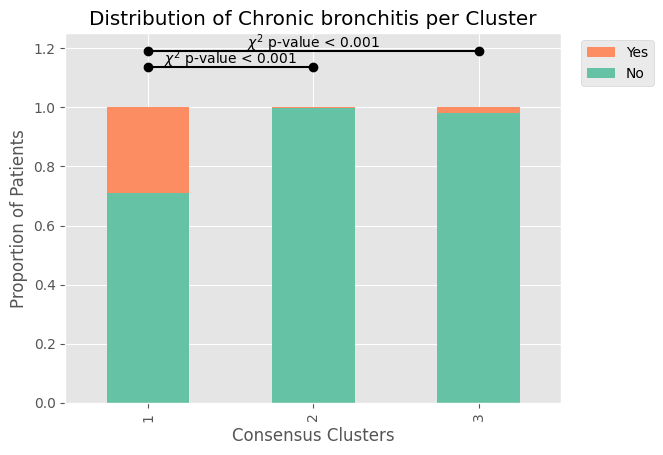

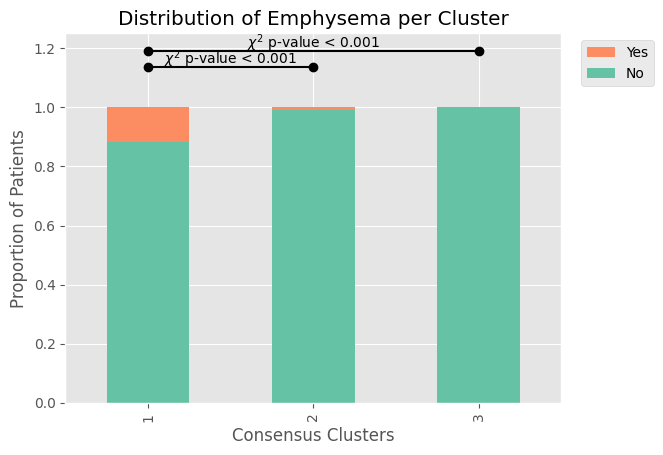

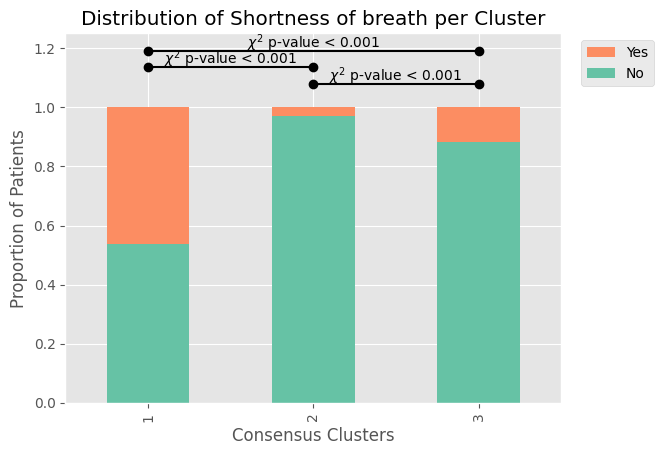

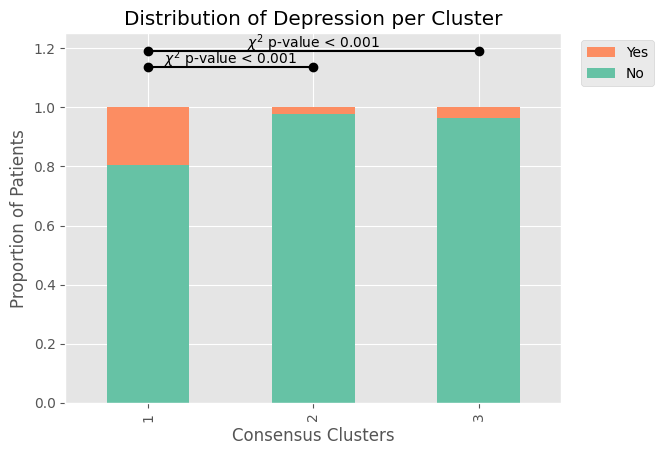

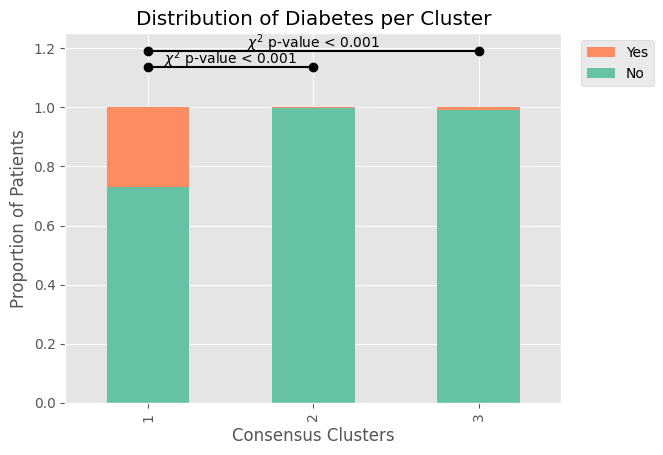

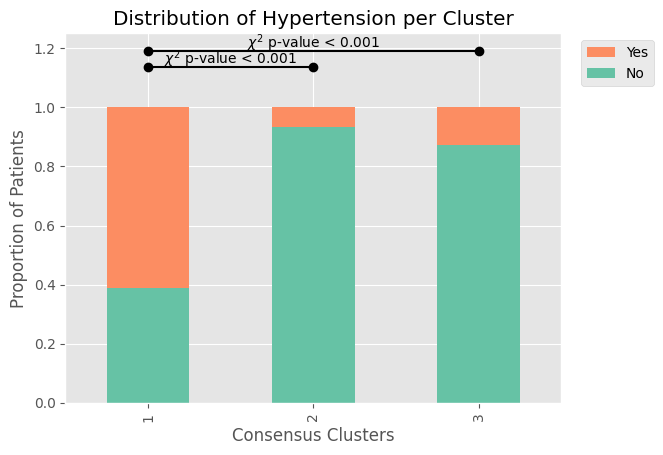

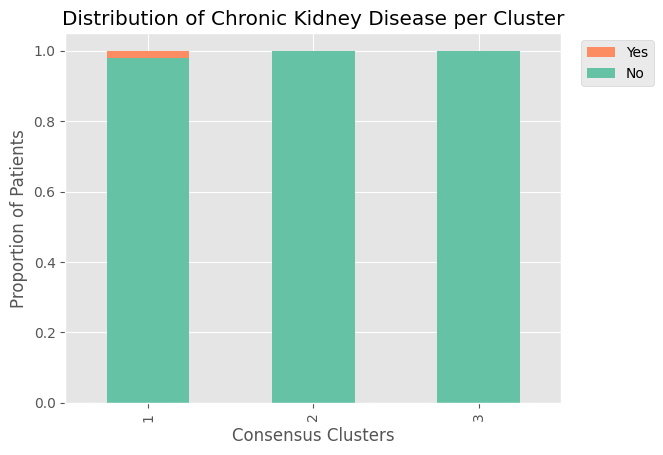

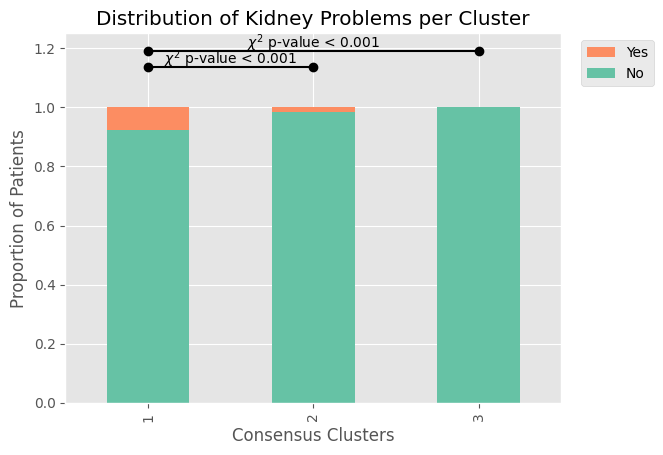

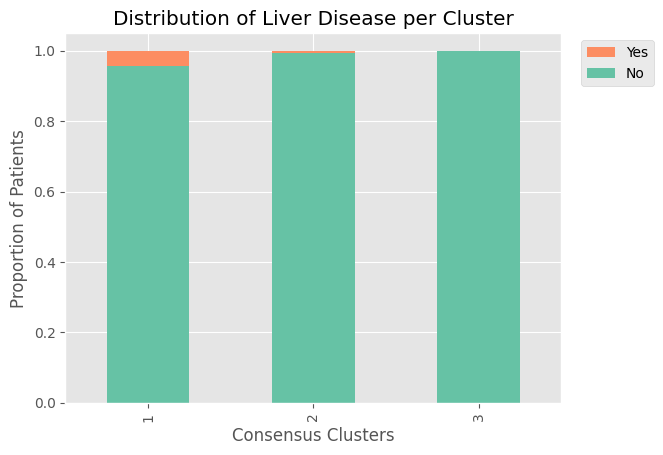

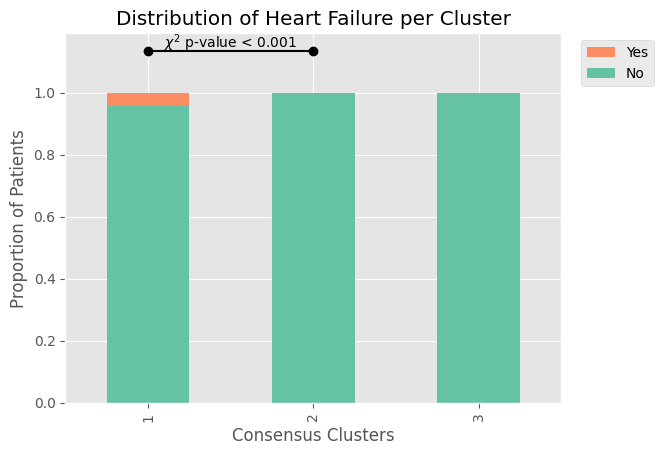

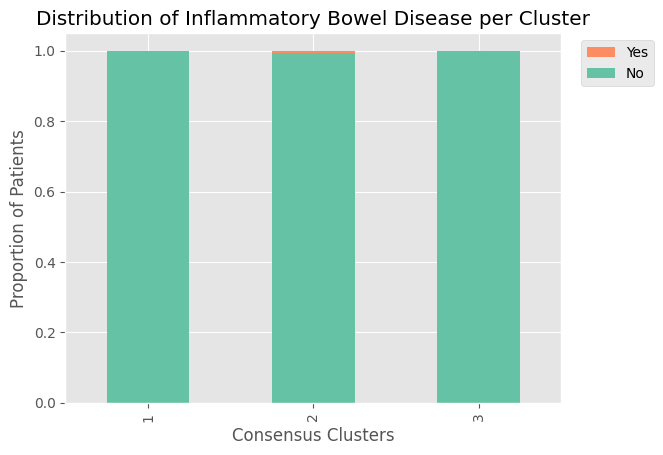

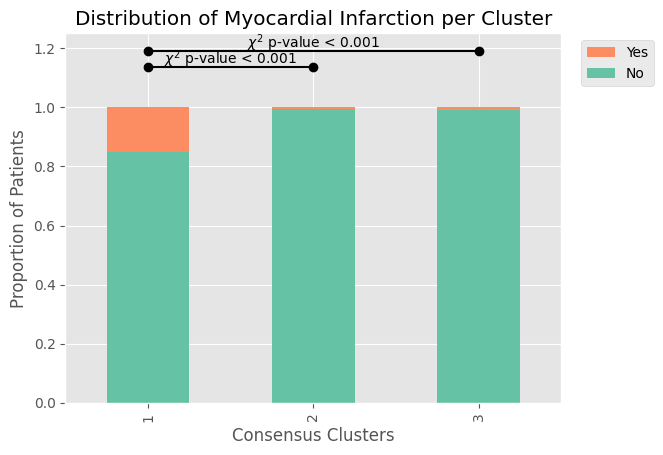

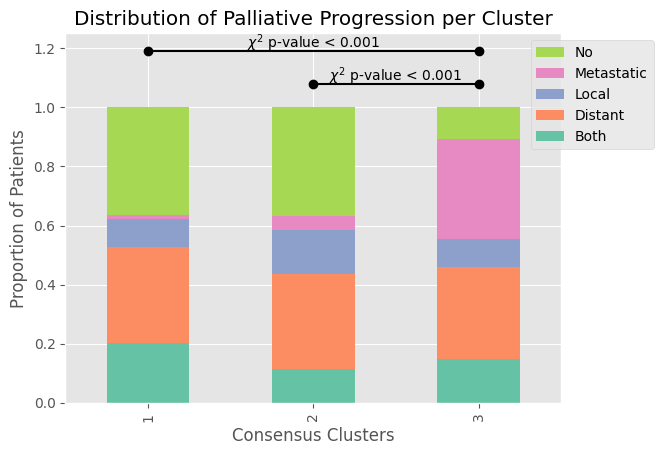

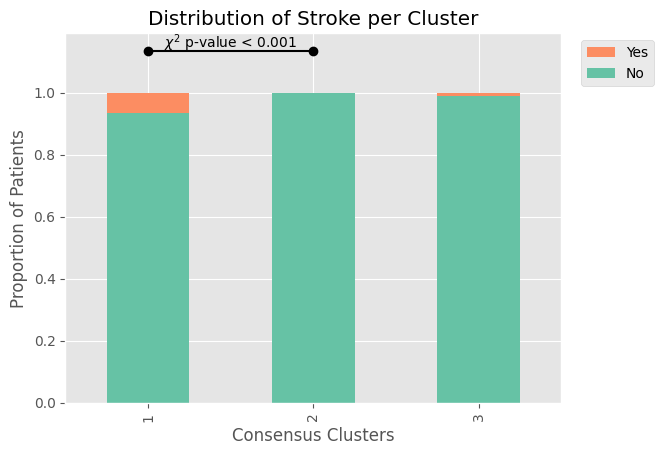

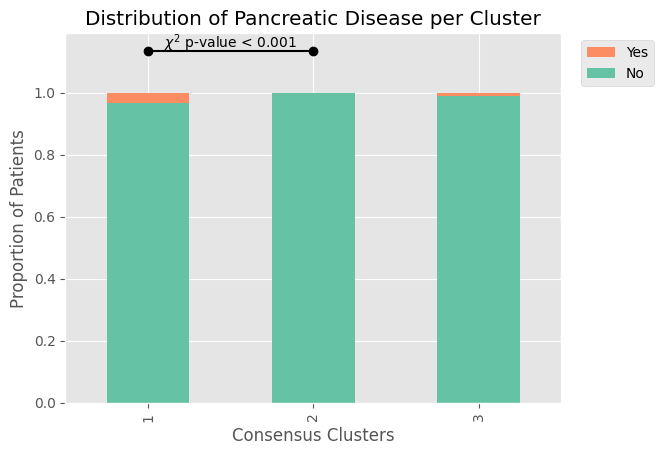

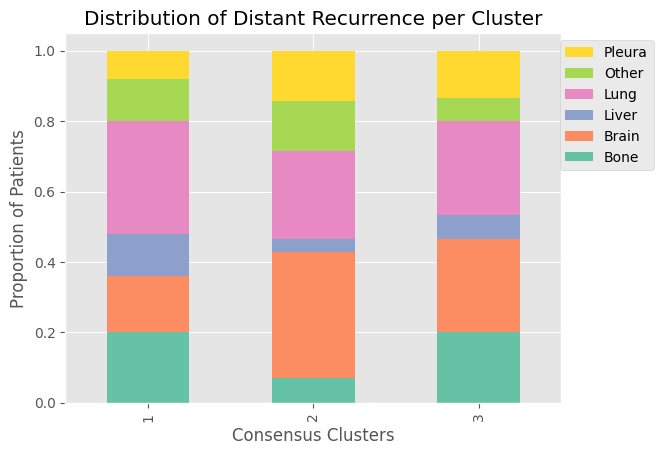

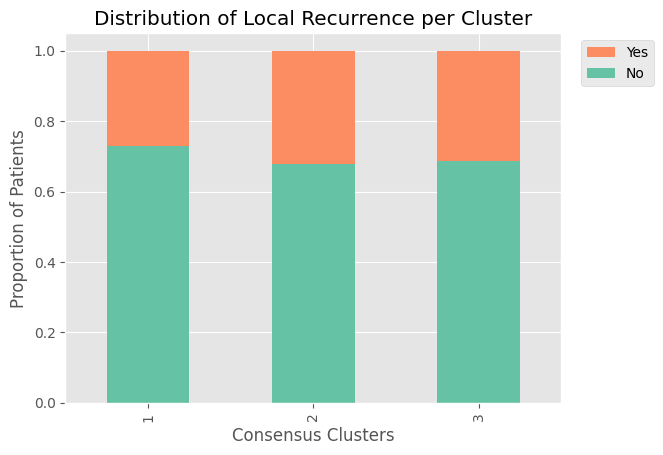

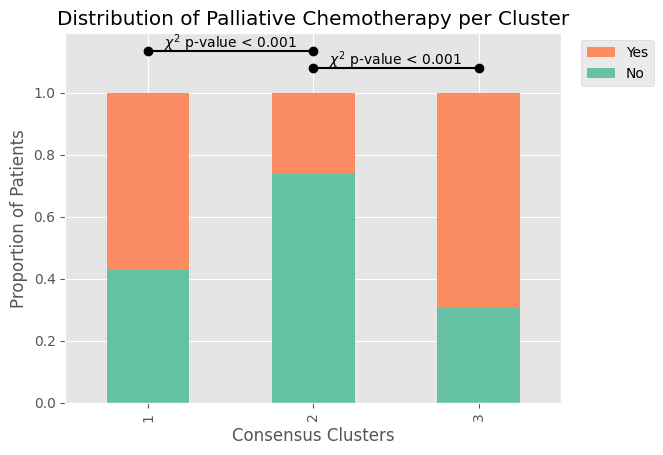

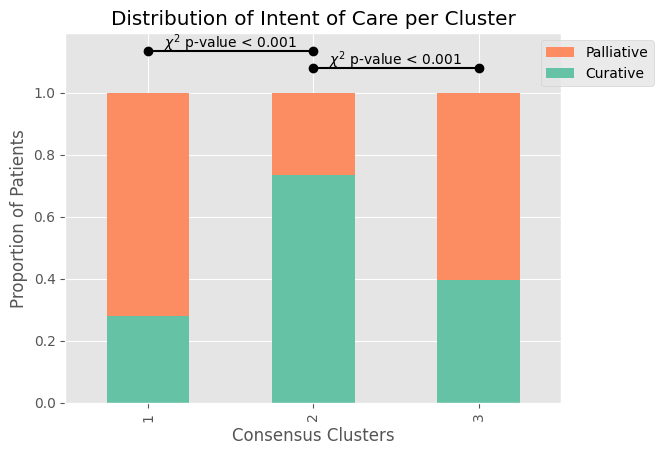

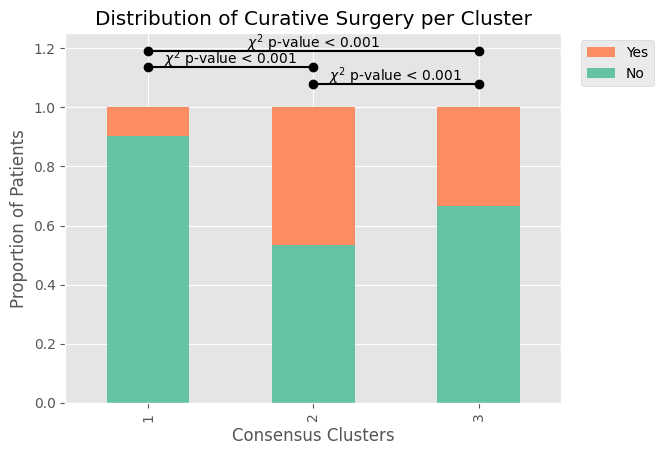

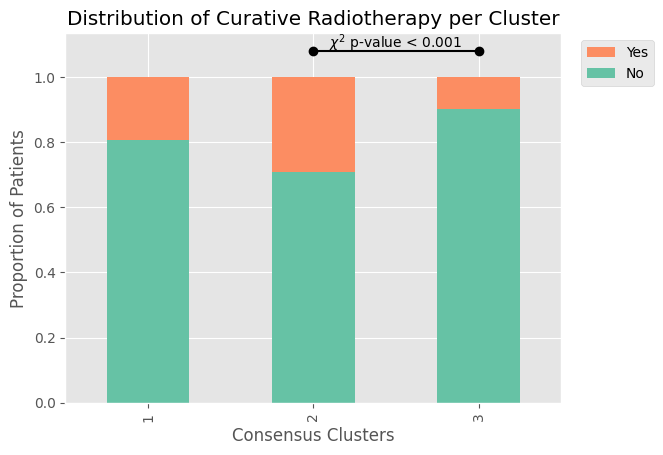

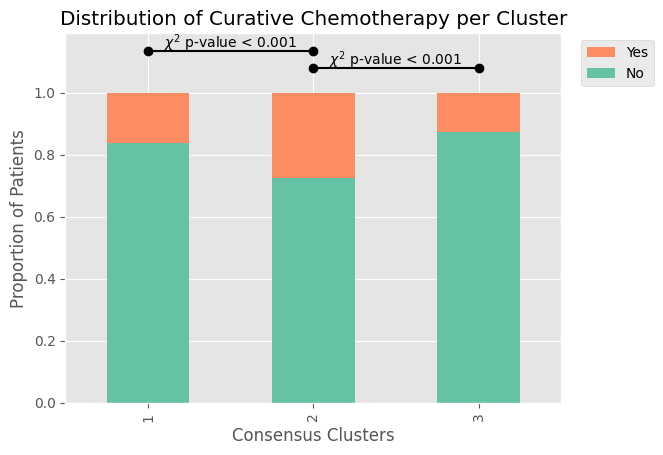

In [91]:
def create_stacked_bar_chart_with_significance(data, variable, title, legend_title, significance_dict):
    sns.set_palette("Set2")

    # Group the data by consensus_clustering and the specified variable, and count the number of occurrences
    grouped_data = data.groupby(['consensus_clustering', variable]).size().unstack()

    # Calculate the proportions by dividing each value by the sum in each cluster
    proportions = grouped_data.div(grouped_data.sum(axis=1), axis=0)

    # Plot the stacked bar chart with the proportions
    ax = proportions.plot(kind='bar', stacked=True)

    # Set chart labels and title
    plt.xlabel('Consensus Clusters')
    plt.ylabel('Proportion of Patients')
    plt.title(title)

    # Reverse the order of handles and labels for the legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1], title=legend_title, loc='upper right', bbox_to_anchor=(1.20, 1))

    # Indicate significance
    for i, (pair, p_value) in enumerate(significance_dict.items()):
        if p_value < 0.05:  # Or use your desired threshold
            # Draw a line between the bars of the clusters
            ax.plot([pair[0] - 1, pair[1] - 1], [i/18 + 1.08, i/18 + 1.08], color='k', marker='o')
            # Annotate the line with '*'
            ax.text((pair[0] + pair[1])/2 - 1, i/18 + 1.09, '$\chi^2$ p-value < 0.001', ha='center')

    # Display the chart
    plt.show()

# Your list of variables
relevant_columns_progression = ['age_category_broad','sex', 'race', 'stage_simple', 'bmi_category',
                        'asbestos_exposure', "alcohol_consumption", 'histology', 
                        'molecular_alteration', 'smoking_status', 'packs_category_broad', 'asbestosis', 
                        'chronic_bronchitis','emphysema', 'shortness_of_breath',
                        'depression','diabetes', 'hypertension','chronic_kidney_disease',
                        'kidney_problems', 'liver_disease', 'heart_failure','inflammatory_bowel_disease',
                        'myocardial infarction', 'palliative_progression', 'stroke', 'pancreatic_disease',
                        'distant_recurrence', 'local_recurrence', 'palliative_chemotherapy',
                        'intent_of_care','curative_surgery','curative_radiotherapy','curative_chemotherapy']

titles = ['Age','Sex', 'Race', 'Stage', 'BMI', 'Asbestos Exposure', "Alcohol Consumption", 'Histology', 
            'Molecular Alteration', 'Smoking Status', 'Pack-Years', 'Asbestosis', 
            'Chronic bronchitis','Emphysema', 'Shortness of breath',
            'Depression','Diabetes', 'Hypertension','Chronic Kidney Disease',
            'Kidney Problems', 'Liver Disease', 'Heart Failure','Inflammatory Bowel Disease',
            'Myocardial Infarction', 'Palliative Progression', 'Stroke', 'Pancreatic Disease',
            'Distant Recurrence', 'Local Recurrence', 'Palliative Chemotherapy',
            'Intent of Care','Curative Surgery','Curative Radiotherapy','Curative Chemotherapy']

def calculate_pairwise_chi2(data, variable, cluster_variable='consensus_clustering'):
    cluster_levels = data[cluster_variable].unique()
    cluster_pairs = list(combinations(cluster_levels, 2))

    p_values = {}
    for pair in cluster_pairs:
        sub_data = data[data[cluster_variable].isin(pair)]
        contingency_table = sub_data.groupby([cluster_variable, variable]).size().unstack().fillna(0)
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        p_values[pair] = p

    return p_values

for variable, title in zip(relevant_columns_progression, titles):
    p_values = calculate_pairwise_chi2(df_analysis_progression, variable)
    create_stacked_bar_chart_with_significance(df_analysis_progression, variable, f'Distribution of {title} per Cluster', "", p_values) 

## Summarizing results in a table

In [92]:
df_analysis_final_consensus.head(1)
quoted_variable_names = ["{}".format(name) for name in df_analysis_final_consensus.columns]
quoted_variable_names

variable_names = ['age_category', 'patient_status', 'sex', 'race', 'marital_status', 'stage','asbestos_exposure','health_status','histology','molecular_alteration',
 'smoking_status','symptoms_past_week','asbestosis','chronic_bronchitis','chronic_kidney_disease','depression','diabetes','distant_recurrence','emphysema',
 'heart_failure','hypertension','inflammatory_bowel_disease','kidney_problems','liver_disease','local_recurrence','myocardial infarction','palliative_progression','pancreatic_disease',
 'shortness_of_breath','stroke','curative_chemotherapy','curative_radiotherapy','curative_surgery','intent_of_care','palliative_chemotherapy','packs_category','bmi_category',
 'survival_overall','packs_per_year',"stage_simple"]

variable_names_new = ['asbestosis','chronic_kidney_disease','depression','diabetes','emphysema',
 'heart_failure','hypertension','inflammatory_bowel_disease','kidney_problems','liver_disease','local_recurrence','myocardial infarction','palliative_progression','pancreatic_disease',
 'stroke','intent_of_care','packs_category']

In [93]:
categorical_variables = df_analysis_final_consensus.select_dtypes(include=['object'])
categorical_summary = categorical_variables.describe(include='all')

In [94]:
# Define a function to format count and percentage
def format_count_percentage(count, total):
    return f"{count} ({(count / total * 100):.1f}%)"

# Get the total number of subjects in each cluster
total_counts = df_analysis_final_consensus['consensus_clustering'].value_counts()

# Placeholder DataFrame for final table
final_table = pd.DataFrame(columns=['Total Cohort', 'Cluster 1', 'Cluster 2', 'Cluster 3'])

# Add total number of subjects to the final table
final_table.loc['Number of subjects'] = [total_counts.sum(), *total_counts.sort_index().values]

# For each feature, compute count and percentage within each cluster
variables = ['stage_simple', 'smoking_status','histology', 'molecular_alteration', 'bmi_category', 'age_category', "sex", "type", "asbestos_exposure", 
             "chronic_bronchitis", "shortness_of_breath", 'race', 'asbestosis','chronic_kidney_disease','depression','diabetes','emphysema',
 'heart_failure','hypertension','inflammatory_bowel_disease','kidney_problems','liver_disease','myocardial infarction','pancreatic_disease',
 'stroke','packs_category']
for feature in variables: # Add other features you're interested in
    
    # Group by cluster and feature and calculate counts
    counts = df_analysis_final_consensus.groupby(['consensus_clustering', feature]).size().unstack(fill_value=0)
    
    # Loop through categories and calculate percentages, then add to final table
    for category in counts.columns:
        row_values = []
        
        # Add the total count and percentage for the total cohort
        total_count = df_analysis_final_consensus[df_analysis_final_consensus[feature] == category].shape[0]
        row_values.append(format_count_percentage(total_count, total_counts.sum()))
        
        # Continue with cluster-specific counts
        for cluster in range(1, 4):
            count = counts.loc[cluster, category] if cluster in counts.index else 0
            total = total_counts[cluster] if cluster in total_counts else 0
            row_values.append(format_count_percentage(count, total))
        
        final_table.loc[f'{feature} - {category}'] = row_values

    # Add an empty row for spacing
    final_table.loc[f'{feature}'] = ["", "", "", ""]

# Apply styles
styled_table_final = final_table.style.set_table_styles([
    {'selector': 'th', 'props': [('background', '#606060'), ('color', 'white'), ('font-family', 'verdana')]},
    {'selector': 'td', 'props': [('font-family', 'verdana'), ('color', 'black')]},
    {'selector': 'tr:nth-of-type(odd)', 'props': [('background', '#f5f5f5')]},
    {'selector': 'tr:nth-of-type(even)', 'props': [('background', 'white')]}
])

styled_table_final

,Total Cohort,Cluster 1,Cluster 2,Cluster 3
Number of subjects,490,93,286,111
stage_simple - I,137 (28.0%),6 (6.5%),102 (35.7%),29 (26.1%)
stage_simple - II,41 (8.4%),1 (1.1%),36 (12.6%),4 (3.6%)
stage_simple - III,108 (22.0%),25 (26.9%),73 (25.5%),10 (9.0%)
stage_simple - IV,204 (41.6%),61 (65.6%),75 (26.2%),68 (61.3%)
stage_simple,,,,
smoking_status - current-smoker,82 (16.7%),22 (23.7%),58 (20.3%),2 (1.8%)
smoking_status - ex-smoker,286 (58.4%),57 (61.3%),220 (76.9%),9 (8.1%)
smoking_status - never-smoker,122 (24.9%),14 (15.1%),8 (2.8%),100 (90.1%)
smoking_status,,,,
